# Лабораторная работа №3  
## Классификация временных рядов и прогнозирование метеоданных шести городов РФ

В notebook реализован полный пайплайн анализа метеоданных:

1. **EDA и проверка качества данных**
2. **Инжиниринг признаков**
3. **Классификация климатического типа по окнам временного ряда**
4. **Прогноз температуры на 30 дней вперёд для каждого города**
5. **Объединение этапов в единый two-stage pipeline**
6. **Интерпретация полученных результатов**

> По условию задания данные для прогнозирования приводятся к **дневной частоте**,  
> а классификация выполняется по **скользящим окнам** с агрегированными статистиками.

## 0. Практические допущения

### Переход к daily-частоте

Исходные данные представлены с почасовой частотой. Для прогноза на месяц вперёд данные агрегируются до дневного уровня, так как это:

- снижает влияние внутрисуточного шума;
- делает горизонт `H=30` естественной задачей прогноза на **30 дней**;
- формирует более устойчивые признаки для моделей машинного обучения.

### Климатические классы

По условию задания каждый климатический тип должен быть представлен как минимум двумя городами. В работе используется следующая прикладная группировка:

- **умеренно-континентальный**: Москва, Санкт-Петербург;
- **морской субтропический**: Сочи, Геленджик;
- **дальневосточный**: Благовещенск, Находка.

In [65]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

import matplotlib.pyplot as plt
import statsmodels.api as sm

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_white

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

In [66]:
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Загрузка данных

In [6]:
CLIMATE_MAP = {
    "Москва": "умеренно-континентальный",
    "Санкт-Петербург": "умеренно-континентальный",
    "Сочи": "морской субтропический",
    "Геленджик": "морской субтропический",
    "Благовещенск": "дальневосточный",
    "Находка": "дальневосточный",
}

BASE_FEATURES = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "weathercode",
    "wind_speed_10m",
    "surface_pressure",
]

DAILY_AGG = {
    "temperature_2m": "mean",
    "relative_humidity_2m": "mean",
    "precipitation": "sum",
    "rain": "sum",
    "snowfall": "sum",
    "weathercode": "median",
    "wind_speed_10m": "mean",
    "surface_pressure": "mean",
}


def load_weather_data(data_dir: str | Path) -> pd.DataFrame:
    data_dir = Path(data_dir)
    frames = []
    for path in sorted(data_dir.glob("*.parquet")):
        city = path.name.split("_")[0]
        table = pq.read_table(path)
        df = table.to_pandas()
        if "time" in df.columns:
            df["time"] = pd.to_datetime(df["time"])
            df = df.set_index("time").sort_index()
        df["city"] = city
        frames.append(df)

    if not frames:
        raise ValueError(f"В {data_dir} не найдено parquet-файлов")

    full = pd.concat(frames).sort_index()
    full["climate_type"] = full["city"].map(CLIMATE_MAP)
    return full


DATA_DIR = 'data'
raw_df = load_weather_data(DATA_DIR)
print(f"DATA_DIR = {DATA_DIR}")
print(raw_df.shape)
display(raw_df.head())

DATA_DIR = data
(368208, 10)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city,climate_type
time,,,,,,,,,,
2019-01-01,-13.7,56,0.0,0.0,0.0,3,12.6,1008.700012,Благовещенск,дальневосточный
2019-01-01,-6.5,92,0.0,0.0,0.0,3,10.8,1000.500000,Москва,умеренно-континентальный
2019-01-01,-13.4,58,0.0,0.0,0.0,0,5.2,1025.500000,Находка,дальневосточный
2019-01-01,-1.8,85,0.0,0.0,0.0,3,23.5,1015.200012,Санкт-Петербург,умеренно-континентальный
2019-01-01,4.6,89,0.2,0.2,0.0,51,8.0,1024.699951,Сочи,морской субтропический


In [7]:
summary_df = (
    raw_df.reset_index()
    .groupby("city")
    .agg(
        start=("time", "min"),
        end=("time", "max"),
        rows=("time", "size"),
        missing_total=("temperature_2m", lambda s: 0),
    )
)

missing_by_city = raw_df.groupby("city")[BASE_FEATURES].apply(lambda x: x.isna().sum().sum())
summary_df["missing_total"] = missing_by_city
display(summary_df)

,start,end,rows,missing_total
city,,,,
Благовещенск,2019-01-01,2025-12-31 23:00:00,61368,0
Геленджик,2019-01-01,2025-12-31 23:00:00,61368,0
Москва,2019-01-01,2025-12-31 23:00:00,61368,0
Находка,2019-01-01,2025-12-31 23:00:00,61368,0
Санкт-Петербург,2019-01-01,2025-12-31 23:00:00,61368,0
Сочи,2019-01-01,2025-12-31 23:00:00,61368,0


### Вывод по загрузке
- данные успешно загружены для 6 городов;
- покрытие: 2019–2025 годы;
- частота исходных данных — **почасовая**;

## 2. Ресемплинг и первичная подготовка

In [9]:
daily_df = (
    raw_df.groupby("city")
    .resample("D")
    .agg(DAILY_AGG)
    .reset_index()
    .sort_values(["city", "time"])
)

daily_df["climate_type"] = daily_df["city"].map(CLIMATE_MAP)

print(daily_df.shape)
display(daily_df.head())

(15342, 11)


,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,climate_type
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,дальневосточный
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,дальневосточный
2,Благовещенск,2019-01-03,-18.770834,70.041667,0.0,0.0,0.0,0.0,8.770833,1010.370850,дальневосточный
3,Благовещенск,2019-01-04,-20.787500,75.166667,0.0,0.0,0.0,3.0,8.083333,1004.587463,дальневосточный
4,Благовещенск,2019-01-05,-19.866667,72.333333,0.0,0.0,0.0,0.0,10.708333,1007.562500,дальневосточный


In [10]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out["time"])
    out["hour"] = getattr(dt.dt, "hour", 0)
    out["dayofweek"] = dt.dt.dayofweek
    out["day"] = dt.dt.day
    out["month"] = dt.dt.month
    out["quarter"] = dt.dt.quarter
    out["year"] = dt.dt.year
    out["dayofyear"] = dt.dt.dayofyear

    out["season"] = np.select(
        [
            out["month"].isin([12, 1, 2]),
            out["month"].isin([3, 4, 5]),
            out["month"].isin([6, 7, 8]),
            out["month"].isin([9, 10, 11]),
        ],
        ["winter", "spring", "summer", "autumn"],
        default="unknown",
    )

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["doy_sin"] = np.sin(2 * np.pi * out["dayofyear"] / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out["dayofyear"] / 365.25)
    return out


daily_df = add_time_features(daily_df)
display(daily_df.head())

,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,quarter,year,dayofyear,season,month_sin,month_cos,hour_sin,hour_cos,doy_sin,doy_cos
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,...,1,2019,1,winter,0.5,0.866025,0.0,1.0,0.017202,0.999852
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,...,1,2019,2,winter,0.5,0.866025,0.0,1.0,0.034398,0.999408
2,Благовещенск,2019-01-03,-18.770834,70.041667,0.0,0.0,0.0,0.0,8.770833,1010.370850,...,1,2019,3,winter,0.5,0.866025,0.0,1.0,0.051584,0.998669
3,Благовещенск,2019-01-04,-20.787500,75.166667,0.0,0.0,0.0,3.0,8.083333,1004.587463,...,1,2019,4,winter,0.5,0.866025,0.0,1.0,0.068755,0.997634
4,Благовещенск,2019-01-05,-19.866667,72.333333,0.0,0.0,0.0,0.0,10.708333,1007.562500,...,1,2019,5,winter,0.5,0.866025,0.0,1.0,0.085906,0.996303


### Обоснование ресемплинга

Для прогноза на месяц вперёд используется daily-частота, так как она лучше отражает медленные погодные изменения и снижает влияние внутрисуточного шума.

При агрегации до дневного уровня:

- температура, влажность, давление и ветер усредняются;
- осадки, дождь и снег суммируются;
- погодный код берётся как медианное или типичное дневное значение.

## 3. EDA — разведочный анализ данных

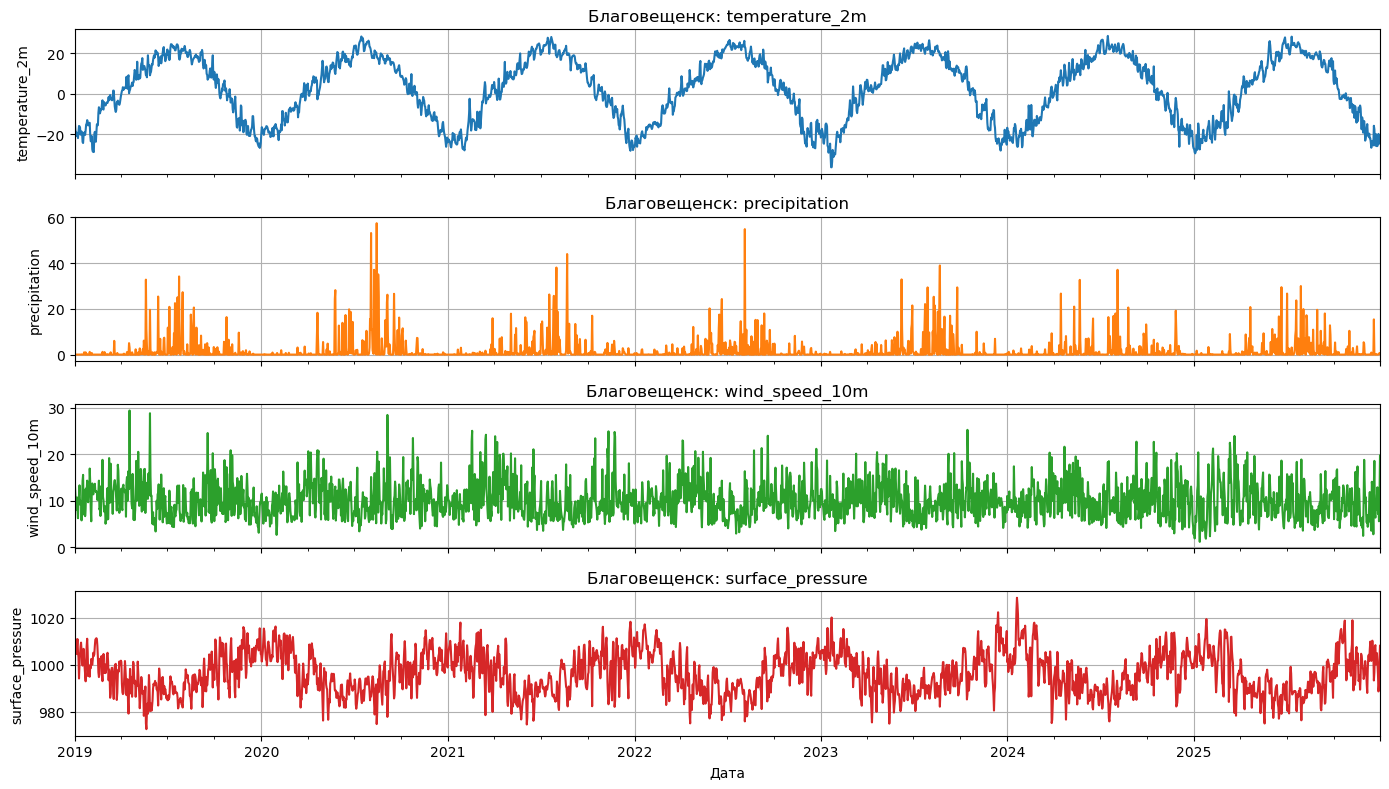

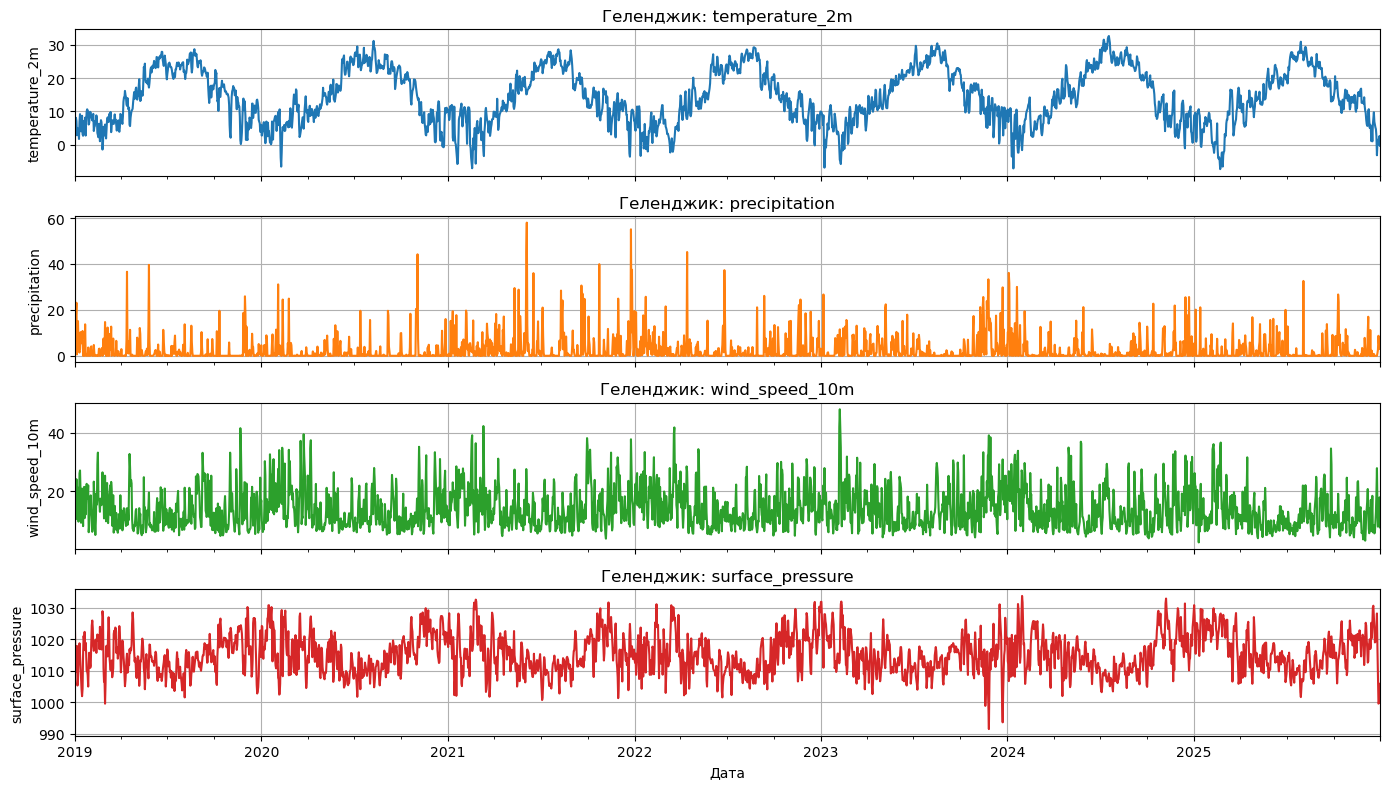

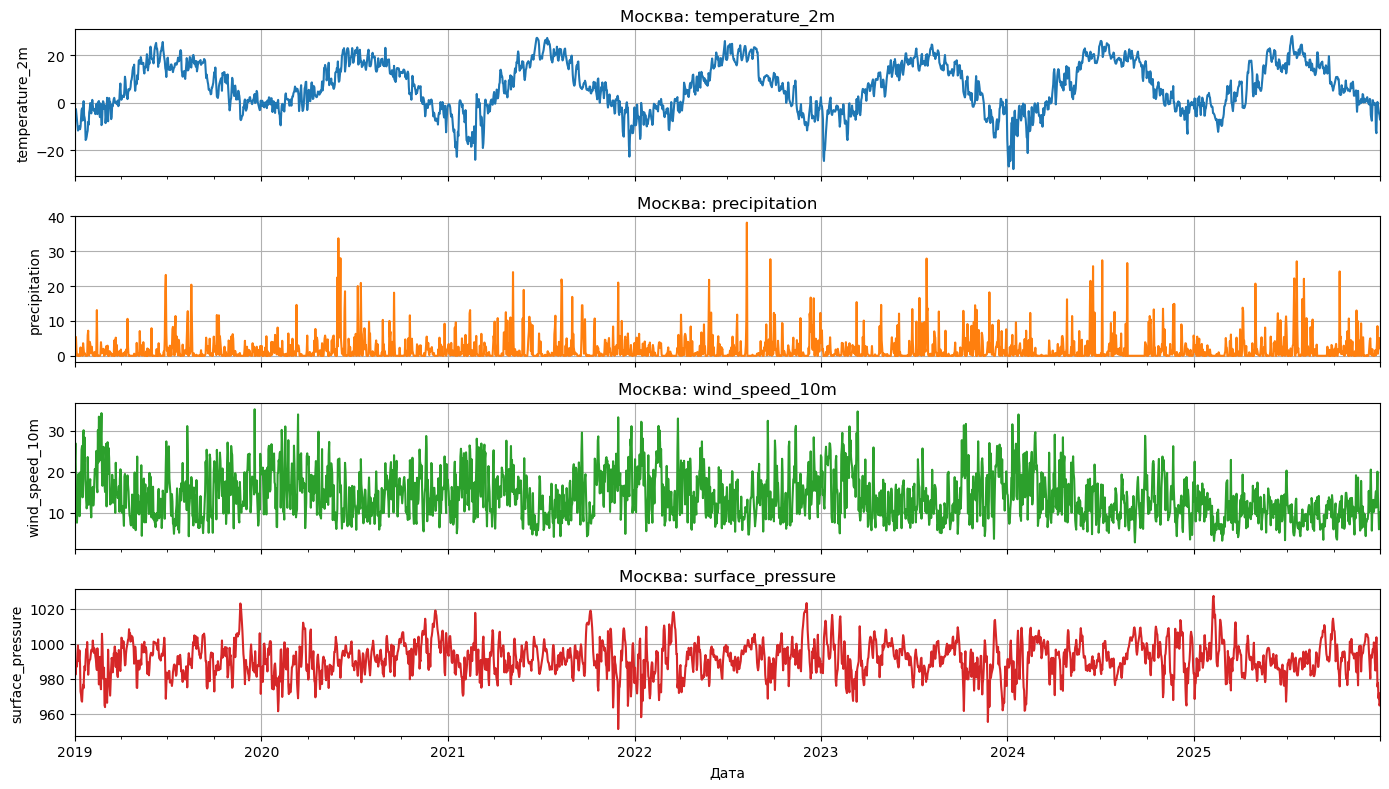

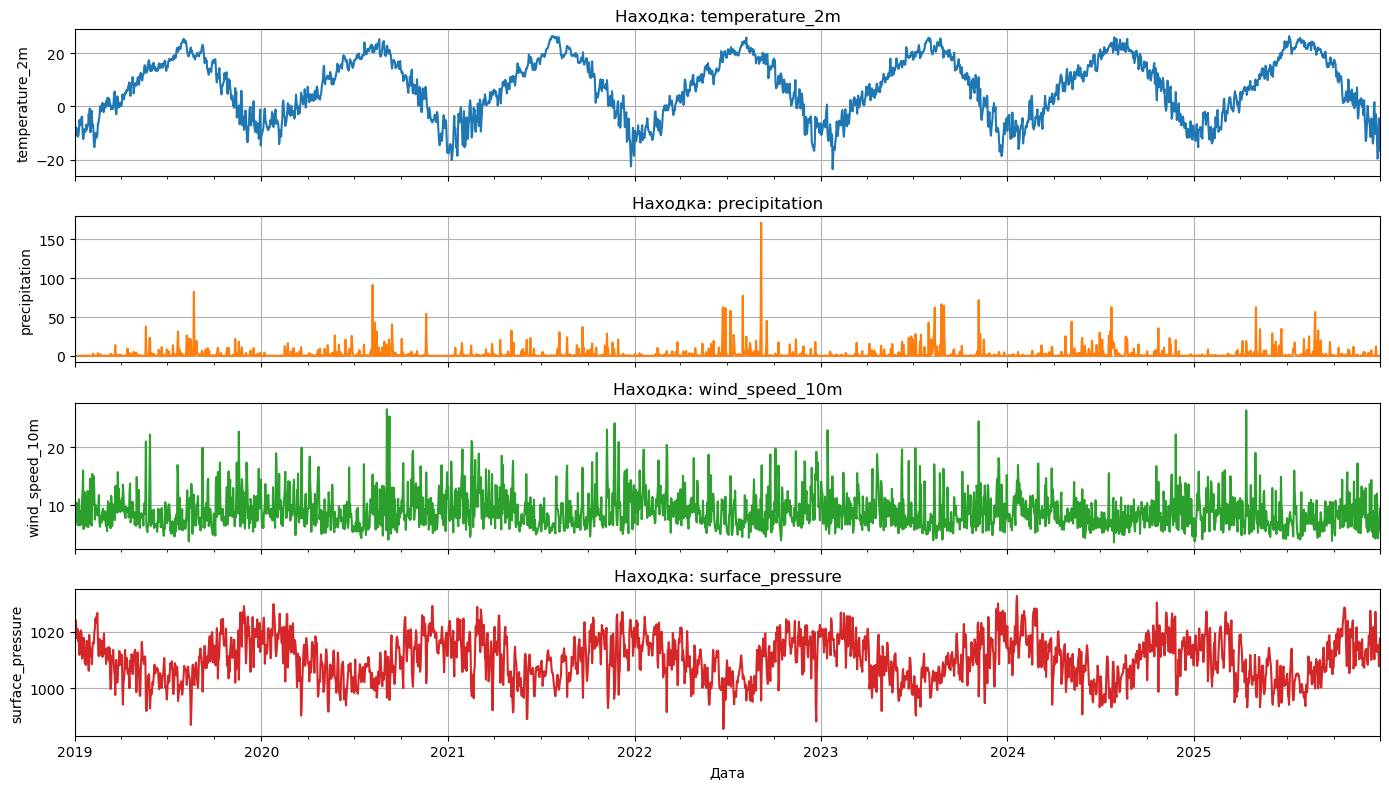

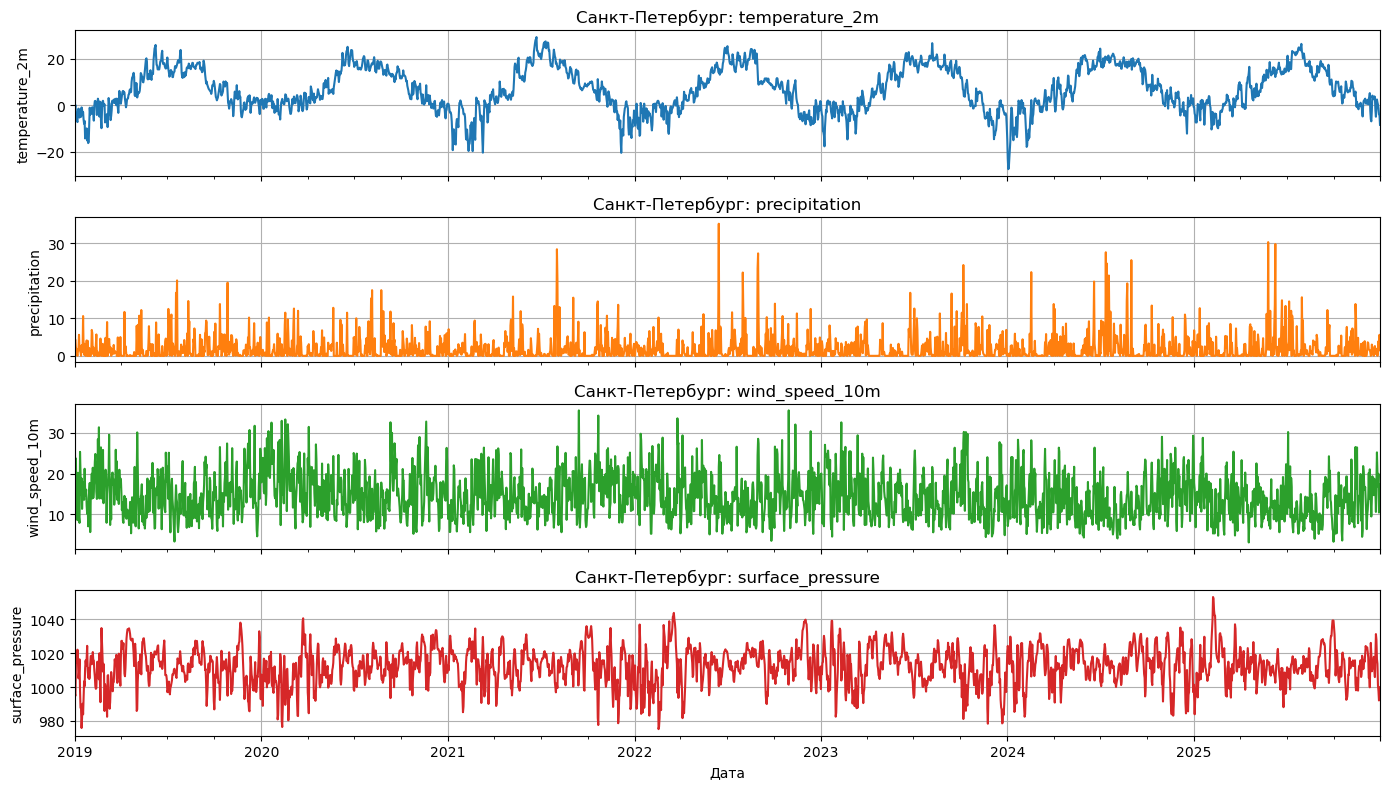

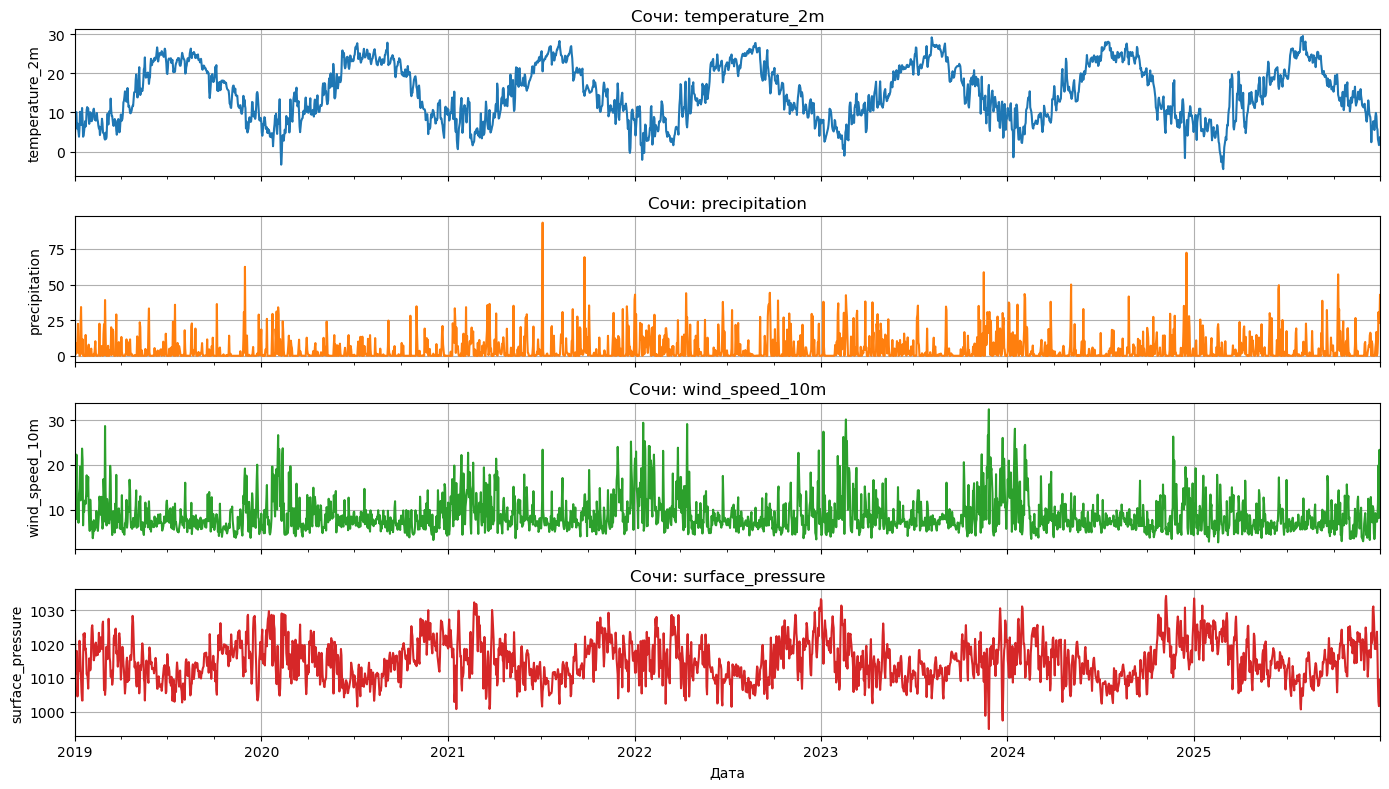

In [16]:
def plot_city_timeseries(
    df: pd.DataFrame,
    city: str,
    cols: list[str],
    date_col: str = "time",
) -> None:
    city_df = (
        df[df["city"] == city]
        .sort_values(date_col)
        .set_index(date_col)
    )

    axes = city_df[cols].plot(
        subplots=True,
        figsize=(14, 8),
        title=[f"{city}: {col}" for col in cols],
        legend=False,
        grid=True,
    )

    for ax, col in zip(axes, cols):
        ax.set_xlabel("Дата")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()


eda_cols = [
    "temperature_2m",
    "precipitation",
    "wind_speed_10m",
    "surface_pressure",
]

for city in sorted(daily_df["city"].unique()):
    plot_city_timeseries(daily_df, city, eda_cols)

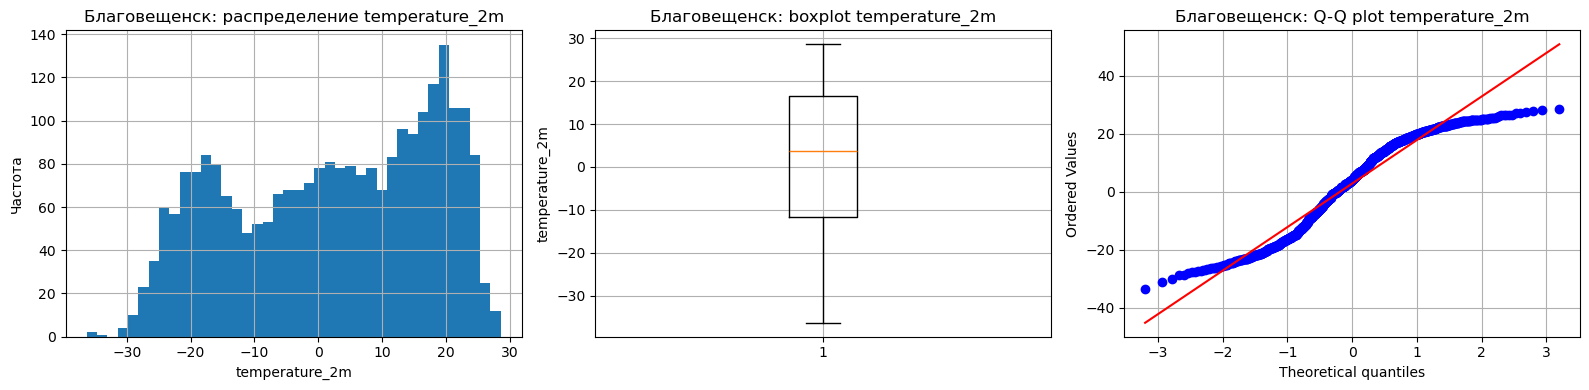

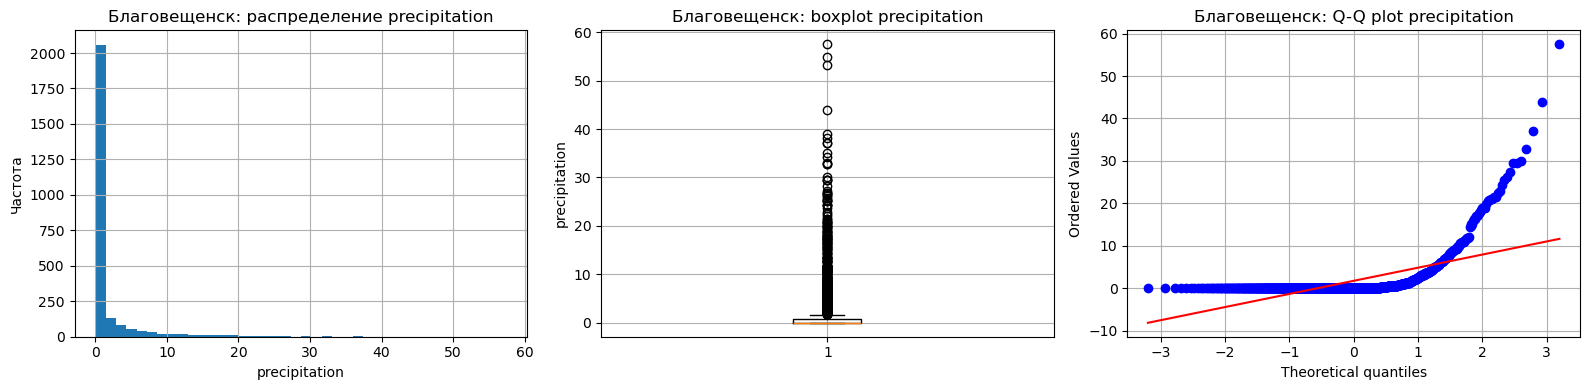

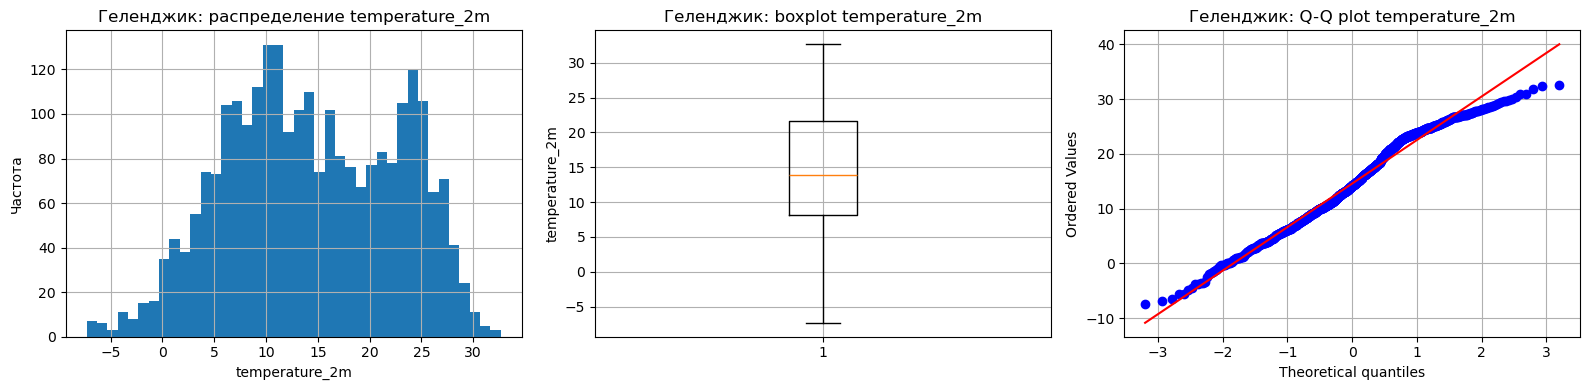

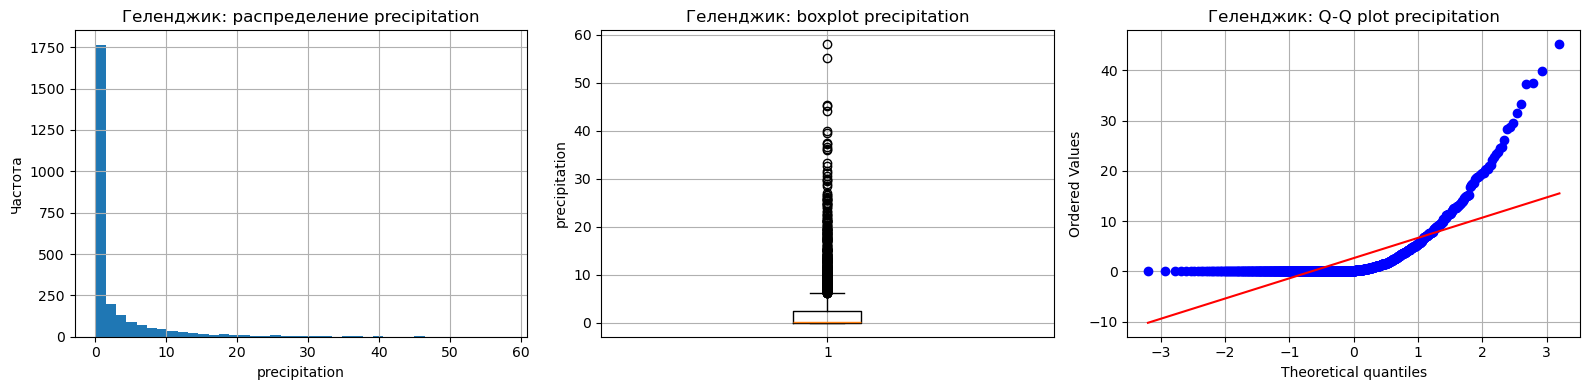

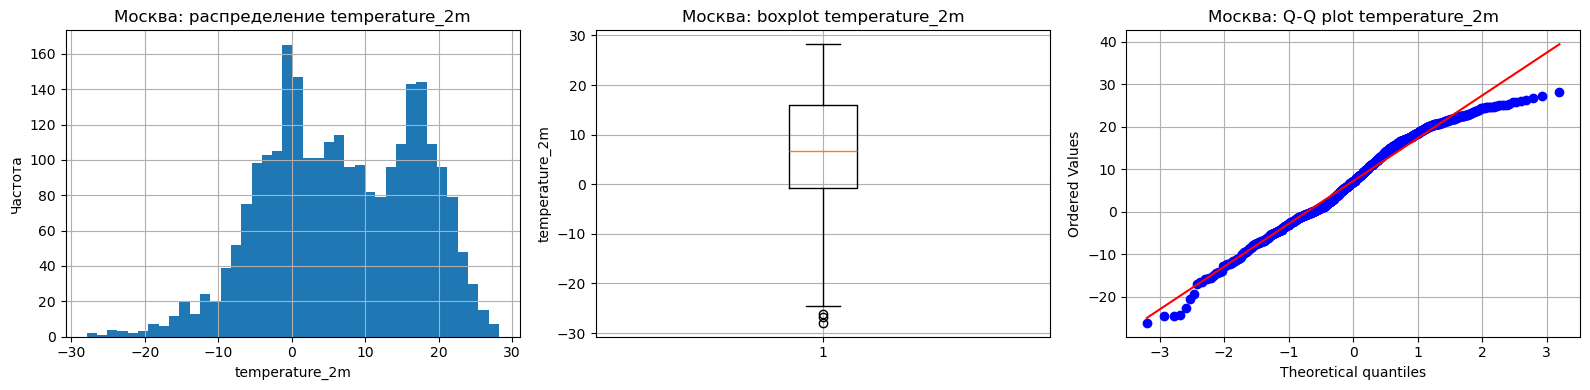

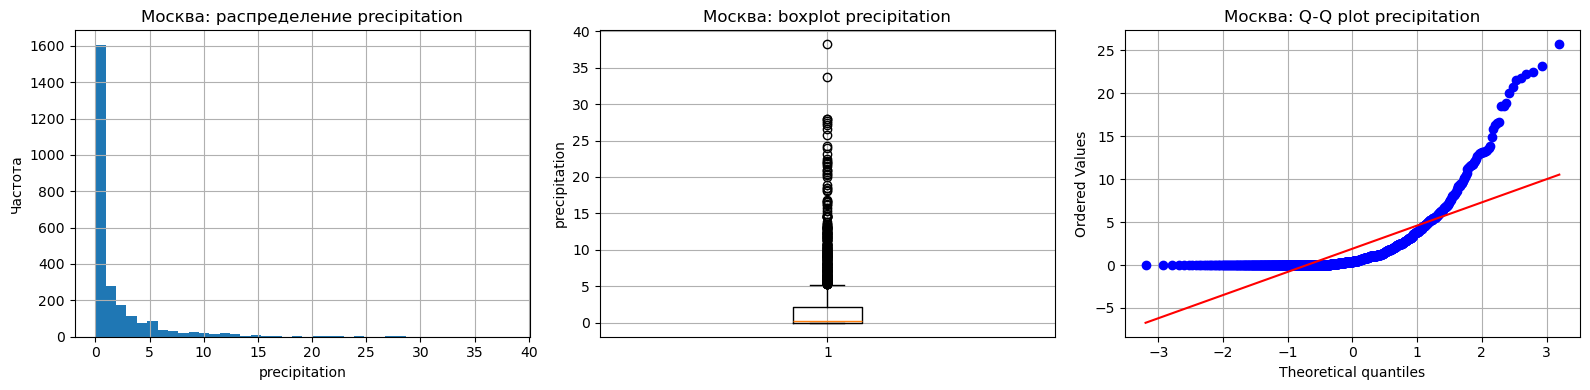

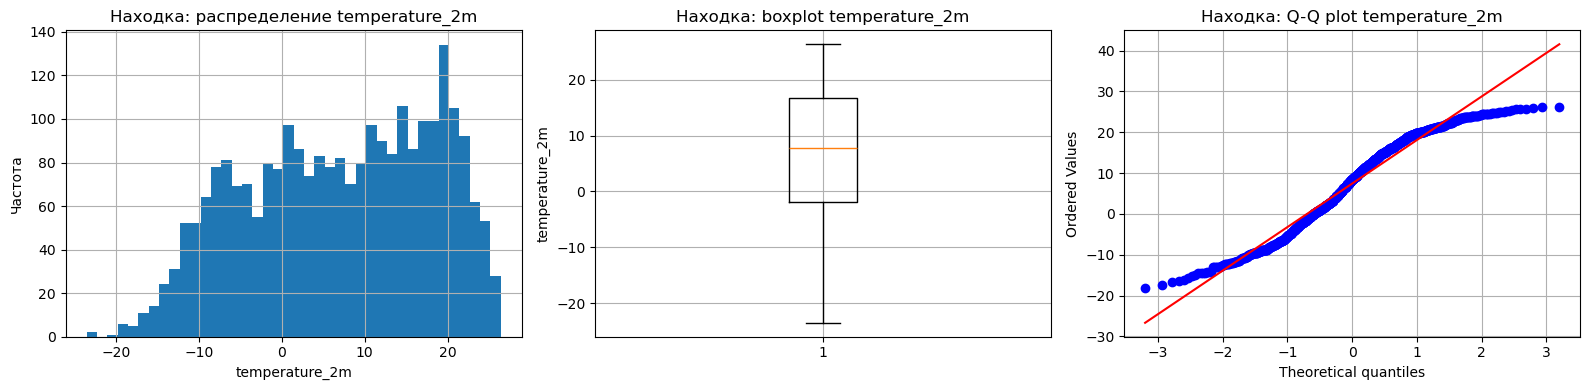

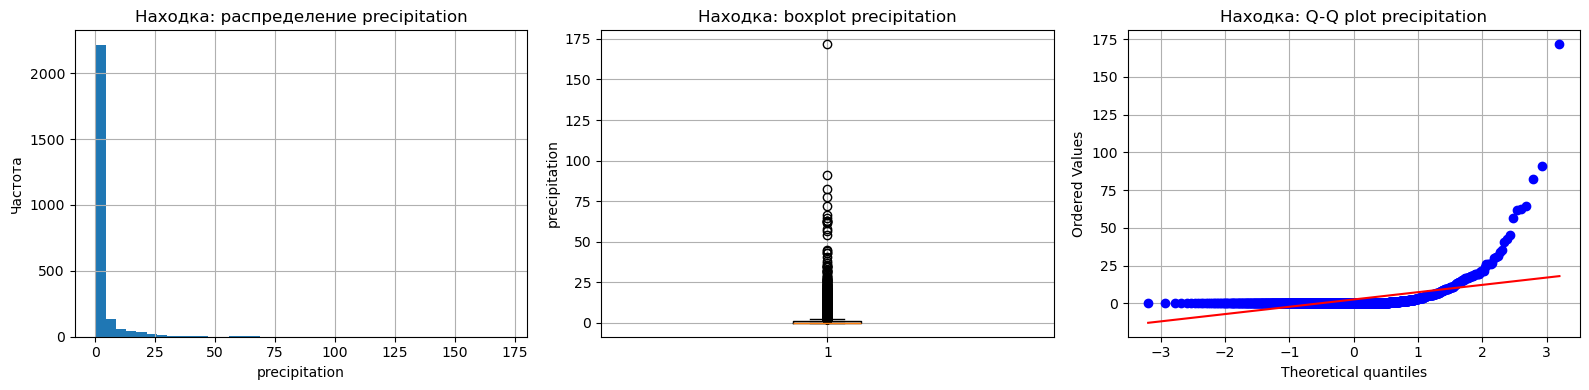

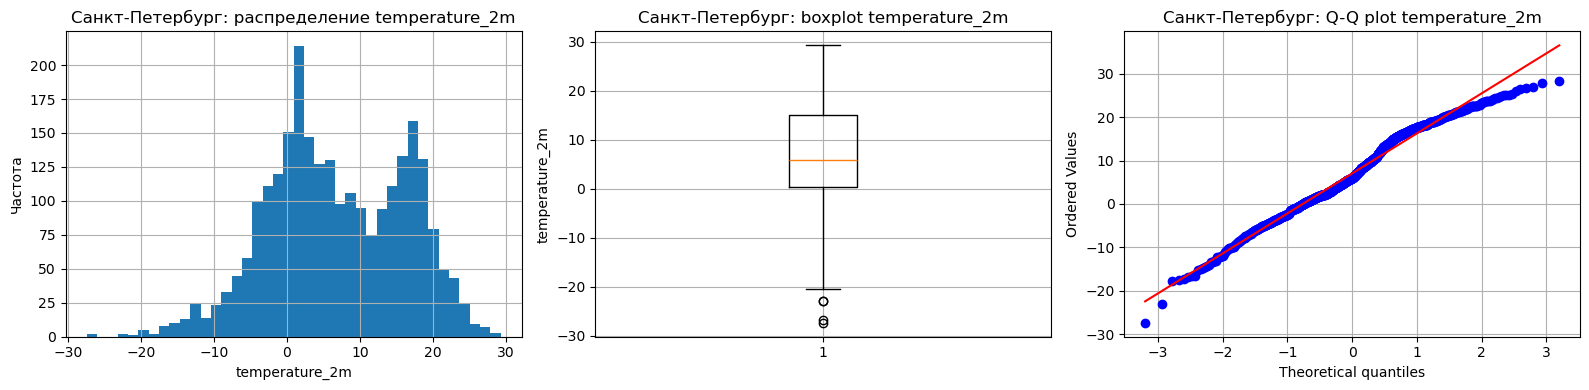

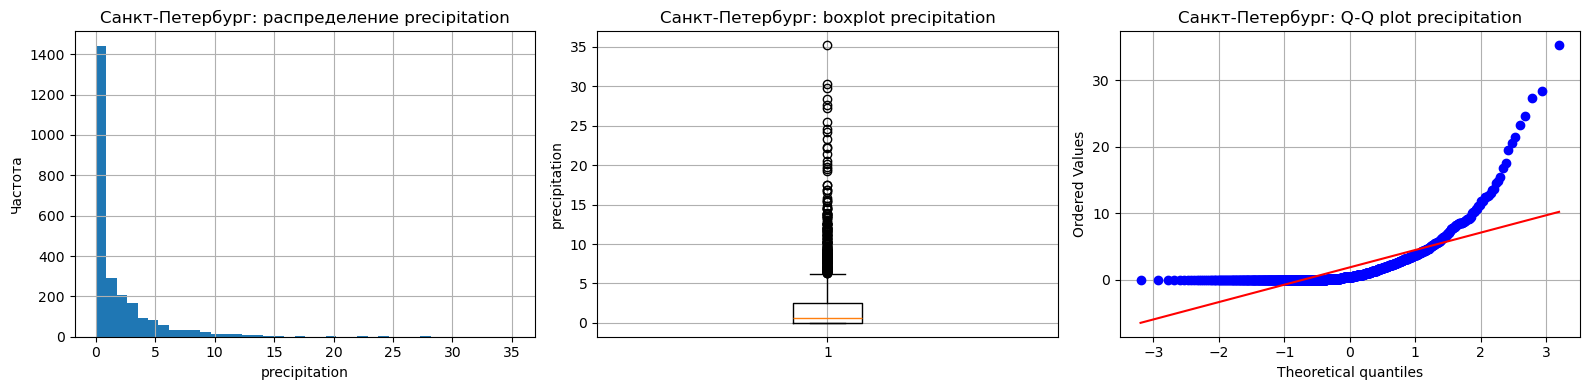

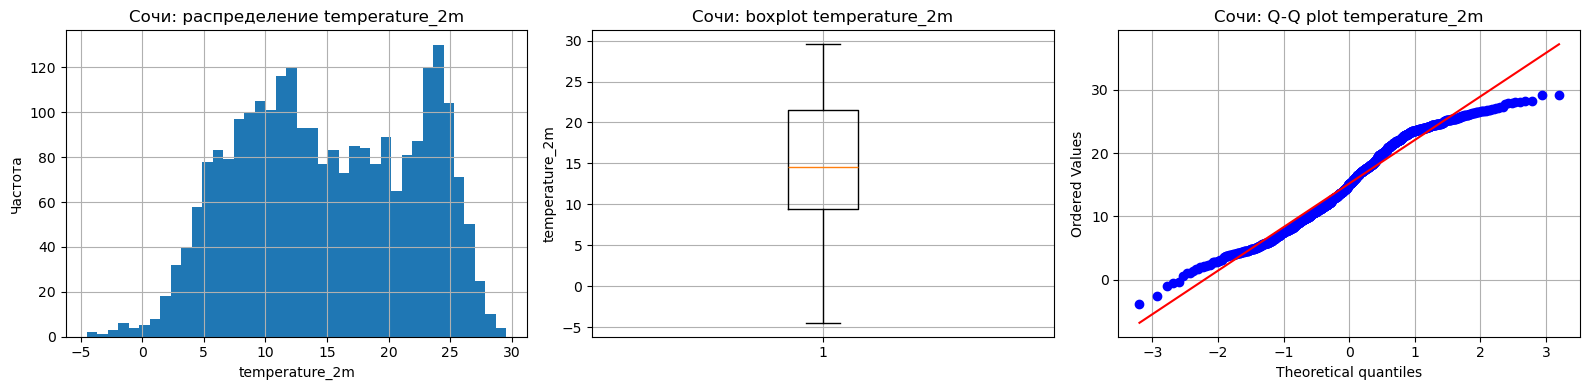

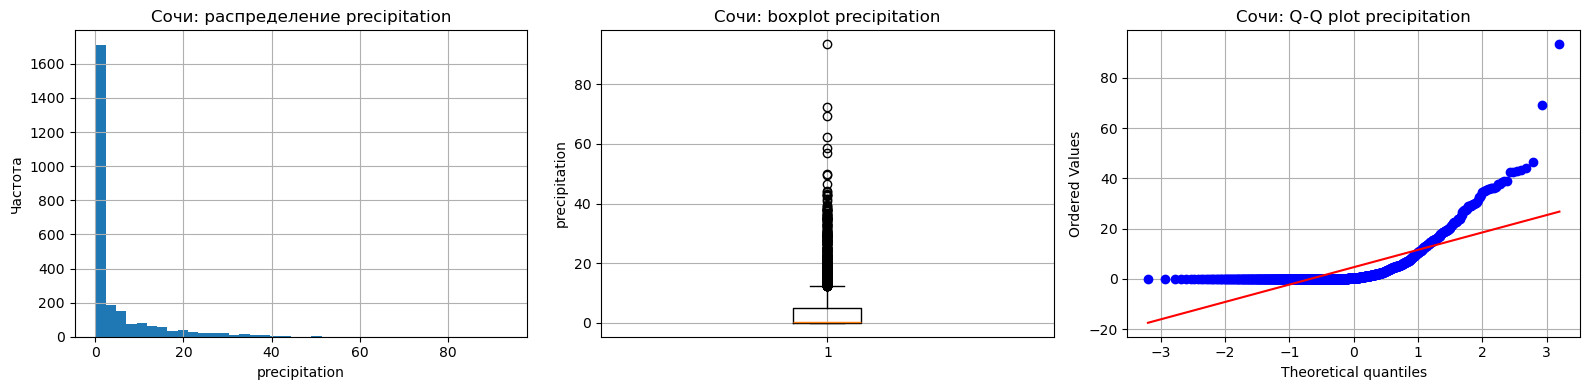

In [17]:
def plot_distributions(
    df: pd.DataFrame,
    city: str,
    cols: list[str],
    date_col: str = "time",
    max_qq_points: int = 1000,
) -> None:
    city_df = df[df["city"] == city].sort_values(date_col)

    for col in cols:
        values = city_df[col].dropna()

        if values.empty:
            print(f"{city}: нет данных для {col}")
            continue

        qq_sample = values.sample(
            min(len(values), max_qq_points),
            random_state=RANDOM_STATE
        )

        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        # Histogram
        axes[0].hist(values, bins=40)
        axes[0].set_title(f"{city}: распределение {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Частота")

        # Boxplot
        axes[1].boxplot(values, vert=True)
        axes[1].set_title(f"{city}: boxplot {col}")
        axes[1].set_ylabel(col)

        # Q-Q plot
        stats.probplot(qq_sample, dist="norm", plot=axes[2])
        axes[2].set_title(f"{city}: Q-Q plot {col}")

        plt.tight_layout()
        plt.show()


distribution_cols = [
    "temperature_2m",
    "precipitation",
]

for city in sorted(daily_df["city"].unique()):
    plot_distributions(daily_df, city, distribution_cols)

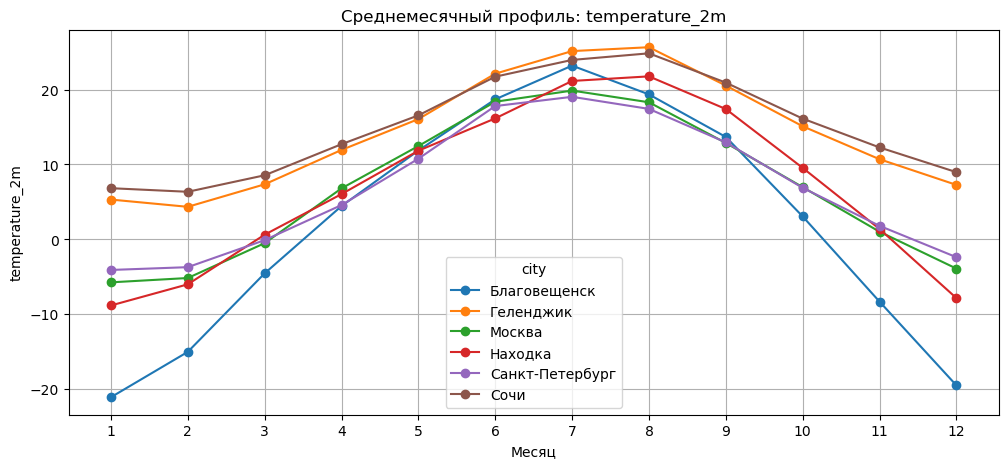

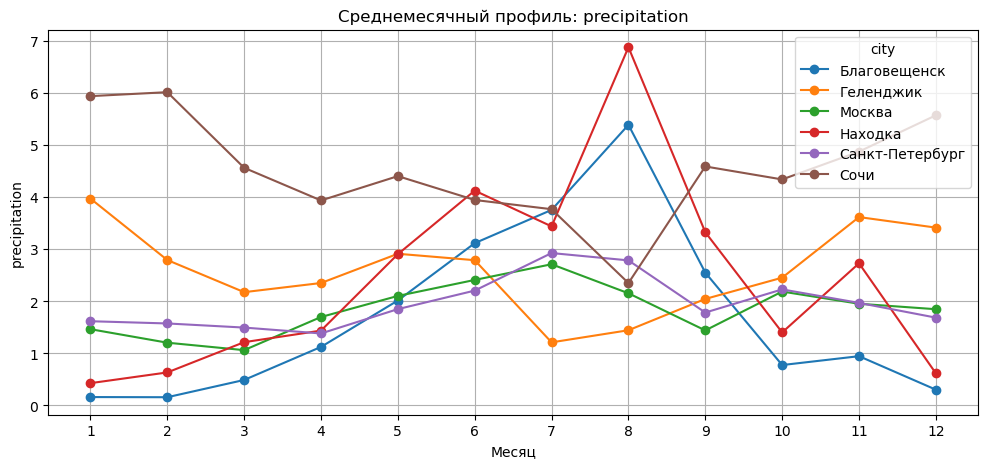

In [18]:
def build_monthly_profiles(
    df: pd.DataFrame,
    group_cols: list[str] = ["city", "month"],
) -> pd.DataFrame:
    """Строит среднемесячные профили погодных признаков по городам."""
    
    agg_rules = {
        "temperature_2m": "mean",
        "precipitation": "mean",
        "wind_speed_10m": "mean",
        "surface_pressure": "mean",
    }

    return (
        df
        .groupby(group_cols, as_index=False)
        .agg(agg_rules)
    )


def plot_monthly_profiles(
    monthly_profiles: pd.DataFrame,
    features: list[str],
    month_col: str = "month",
    city_col: str = "city",
) -> None:
    """Визуализирует среднемесячные профили признаков по городам."""
    
    for feature in features:
        pivot = monthly_profiles.pivot(
            index=month_col,
            columns=city_col,
            values=feature
        )

        ax = pivot.plot(
            marker="o",
            figsize=(12, 5),
            title=f"Среднемесячный профиль: {feature}",
            grid=True
        )

        ax.set_xlabel("Месяц")
        ax.set_ylabel(feature)
        plt.xticks(range(1, 13))
        plt.show()


monthly_profiles = build_monthly_profiles(daily_df)

plot_monthly_profiles(
    monthly_profiles,
    features=["temperature_2m", "precipitation"]
)

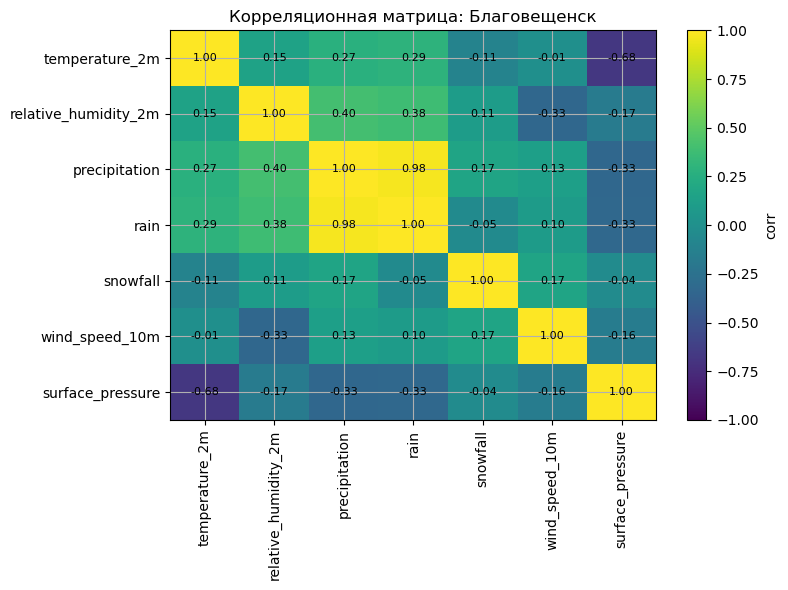

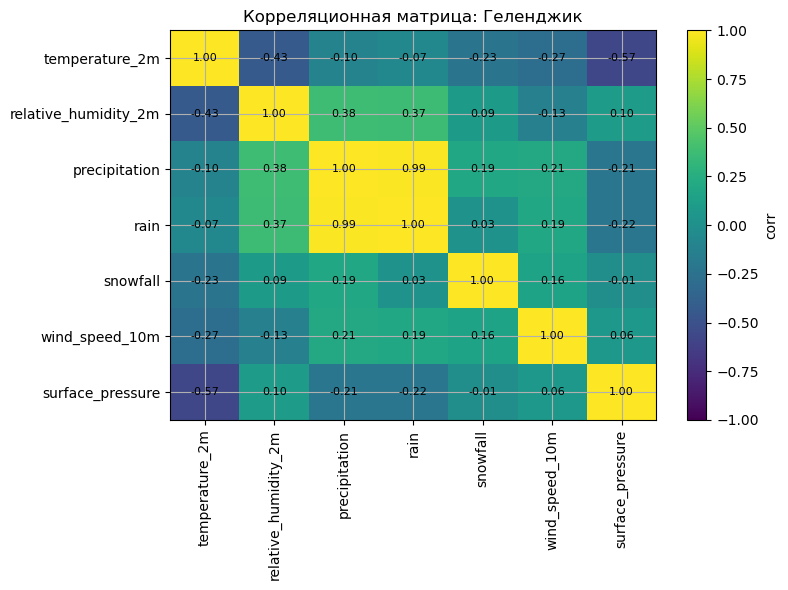

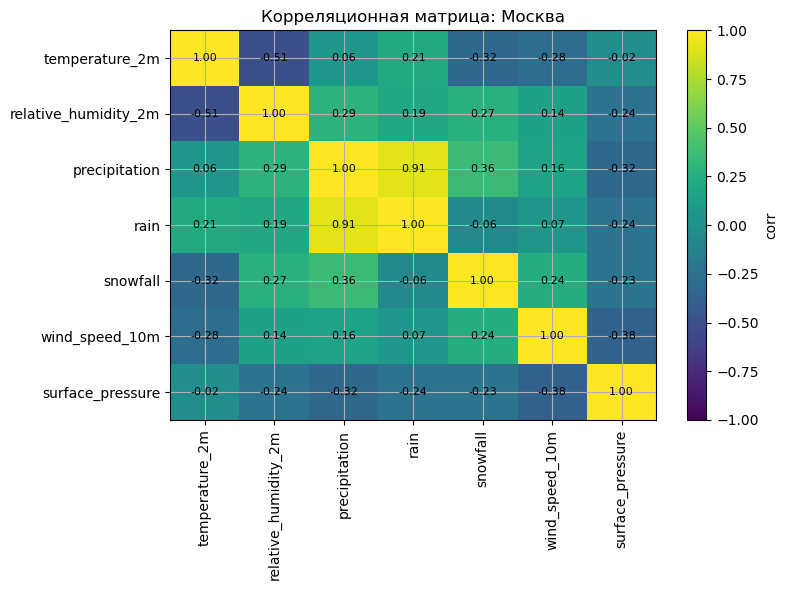

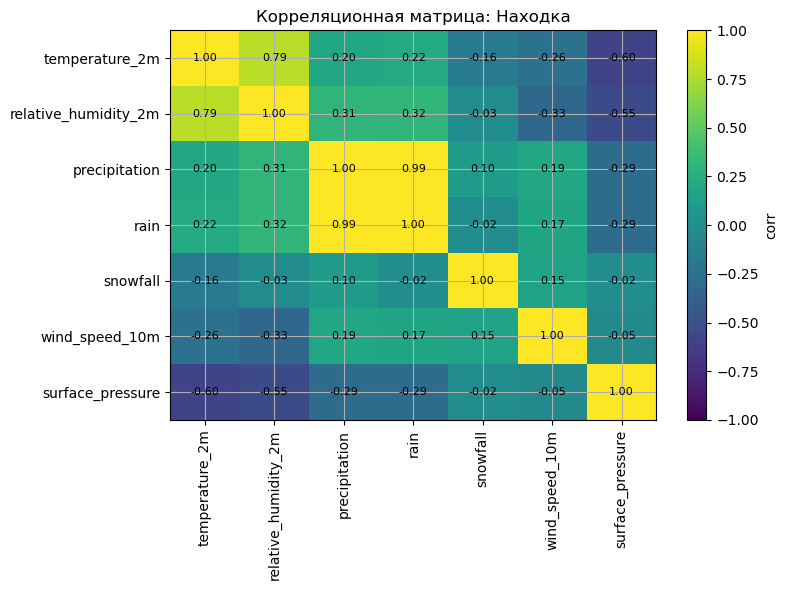

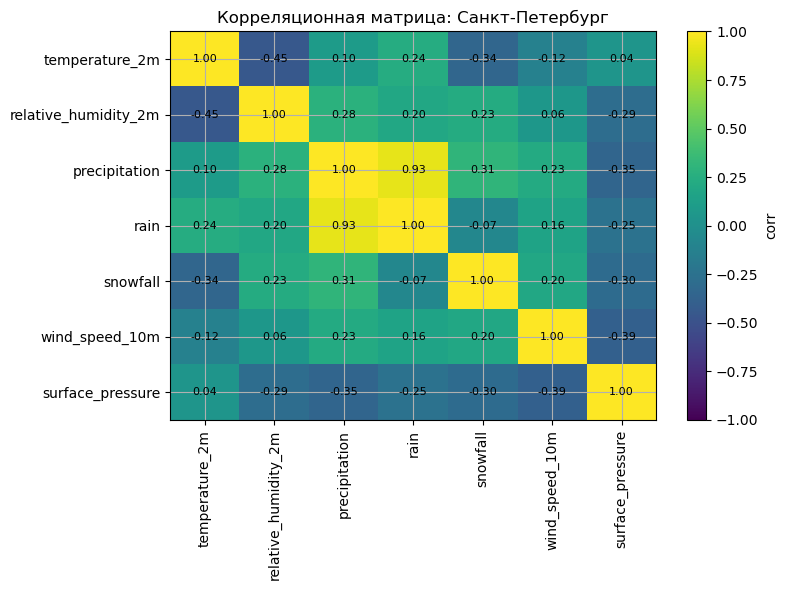

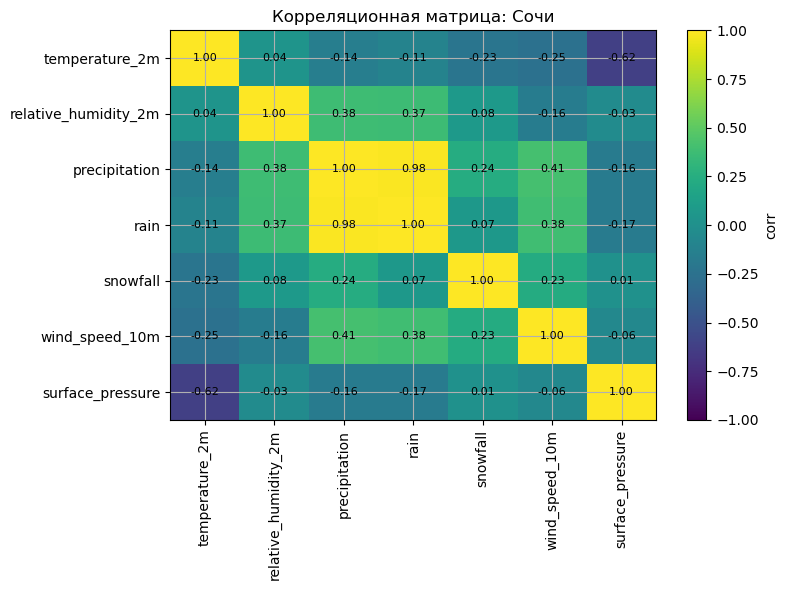

In [19]:
corr_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "surface_pressure",
]


def plot_city_corr_matrix(
    df: pd.DataFrame,
    city: str,
    features: list[str],
) -> None:
    city_df = df[df["city"] == city]
    corr = city_df[features].corr()

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(
        corr,
        aspect="auto",
        vmin=-1,
        vmax=1
    )

    ax.set_title(f"Корреляционная матрица: {city}")

    ax.set_xticks(range(len(features)))
    ax.set_xticklabels(features, rotation=90)

    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features)

    # Подписи значений корреляции
    for i in range(len(features)):
        for j in range(len(features)):
            ax.text(
                j,
                i,
                f"{corr.iloc[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8
            )

    plt.colorbar(im, ax=ax, label="corr")
    plt.tight_layout()
    plt.show()


for city in sorted(daily_df["city"].unique()):
    plot_city_corr_matrix(daily_df, city, corr_features)

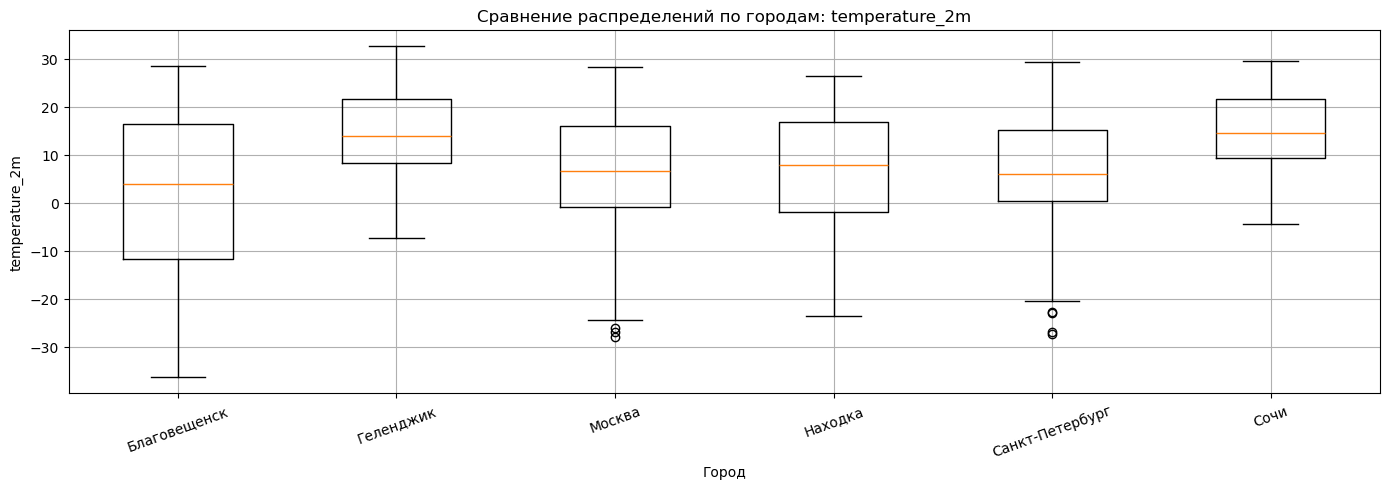

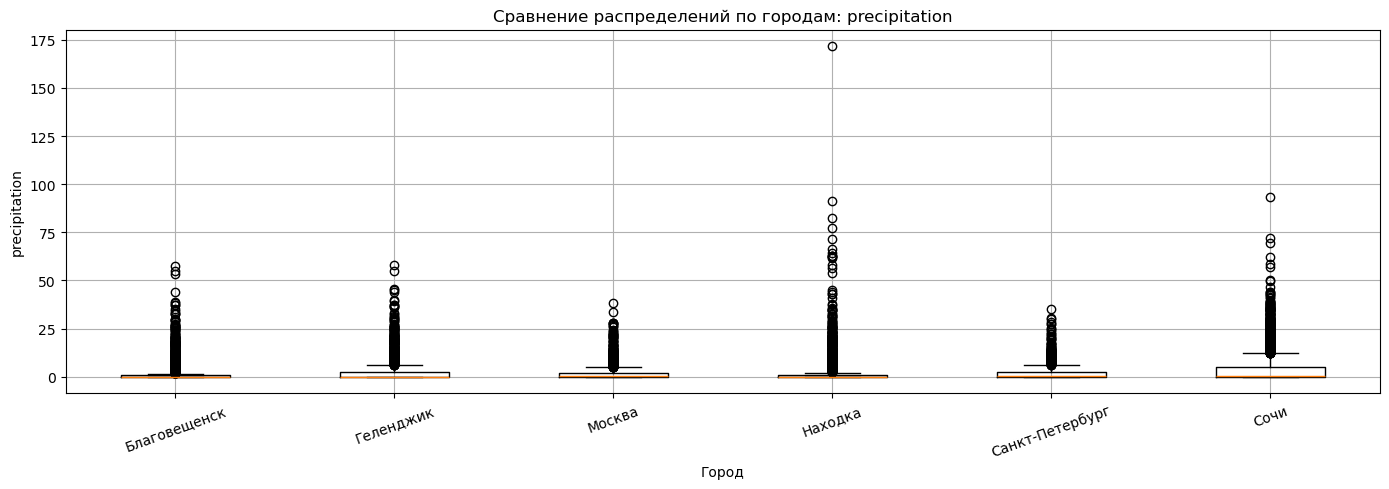

In [20]:
def plot_city_boxplots(
    df: pd.DataFrame,
    features: list[str],
    city_col: str = "city",
) -> None:
    cities = sorted(df[city_col].unique())

    for feature in features:
        data = [
            df.loc[df[city_col] == city, feature].dropna().values
            for city in cities
        ]

        fig, ax = plt.subplots(figsize=(14, 5))

        ax.boxplot(
            data,
            tick_labels=cities,
            showfliers=True
        )

        ax.set_title(f"Сравнение распределений по городам: {feature}")
        ax.set_xlabel("Город")
        ax.set_ylabel(feature)

        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()


comparison_features = [
    "temperature_2m",
    "precipitation",
]

plot_city_boxplots(daily_df, comparison_features)

In [21]:
missing_report = (
    raw_df[BASE_FEATURES + ["city"]]
    .groupby("city")
    .apply(lambda x: x.isna().sum())
)
display(missing_report)

print("Итог по пропускам:")
print(raw_df[BASE_FEATURES].isna().sum().sort_values(ascending=False))

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure
city,,,,,,,,
Благовещенск,0,0,0,0,0,0,0,0
Геленджик,0,0,0,0,0,0,0,0
Москва,0,0,0,0,0,0,0,0
Находка,0,0,0,0,0,0,0,0
Санкт-Петербург,0,0,0,0,0,0,0,0
Сочи,0,0,0,0,0,0,0,0


Итог по пропускам:
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
snowfall                0
weathercode             0
wind_speed_10m          0
surface_pressure        0
dtype: int64


### Обоснование обработки пропусков

Для метеоданных пропуски важно обрабатывать с учётом временной структуры ряда. Базовая стратегия:

- короткие разрывы восстанавливаются через **time interpolation**;
- длинные разрывы — по сезонной норме или соседним аналогичным периодам;
- при отсутствии значимых пропусков дополнительное восстановление не применяется.

В данном наборе пропусков мало, поэтому данные можно использовать практически без дополнительной обработки.

In [22]:
def adf_report(df: pd.DataFrame, col: str = "temperature_2m") -> pd.DataFrame:
    rows = []
    for city, g in df.groupby("city"):
        series = g.sort_values("time")[col].dropna()
        stat, pvalue, *_ = adfuller(series)
        rows.append({"city": city, "feature": col, "adf_pvalue": pvalue, "stationary_at_5pct": pvalue < 0.05})
    return pd.DataFrame(rows).sort_values("adf_pvalue")


adf_results = adf_report(daily_df, "temperature_2m")
display(adf_results)

,city,feature,adf_pvalue,stationary_at_5pct
0,Благовещенск,temperature_2m,0.013476,True
4,Санкт-Петербург,temperature_2m,0.020960,True
2,Москва,temperature_2m,0.022534,True
5,Сочи,temperature_2m,0.026736,True
1,Геленджик,temperature_2m,0.033897,True
3,Находка,temperature_2m,0.051902,False


In [24]:
# Дифференцирование
daily_df["temperature_diff_1"] = daily_df.groupby("city")["temperature_2m"].diff()
daily_df["pressure_growth"] = daily_df.groupby("city")["surface_pressure"].pct_change()
daily_df["temp_velocity"] = daily_df.groupby("city")["temperature_2m"].diff()
daily_df["temp_acceleration"] = daily_df.groupby("city")["temp_velocity"].diff()

display(
    daily_df[["city", "time", "temperature_2m", "temperature_diff_1", "temp_velocity", "temp_acceleration", "pressure_growth"]].head(10)
)

,city,time,temperature_2m,temperature_diff_1,temp_velocity,temp_acceleration,pressure_growth
0,Благовещенск,2019-01-01,-14.037499,NaN,NaN,NaN,NaN
1,Благовещенск,2019-01-02,-18.391666,-4.354167,-4.354167,NaN,0.002533
2,Благовещенск,2019-01-03,-18.770834,-0.379168,-0.379168,3.974999,-0.000540
3,Благовещенск,2019-01-04,-20.787500,-2.016666,-2.016666,-1.637499,-0.005724
4,Благовещенск,2019-01-05,-19.866667,0.920834,0.920834,2.937500,0.002961
5,Благовещенск,2019-01-06,-19.300001,0.566666,0.566666,-0.354168,0.003321
6,Благовещенск,2019-01-07,-21.875000,-2.574999,-2.574999,-3.141665,-0.005391
7,Благовещенск,2019-01-08,-18.850000,3.025000,3.025000,5.599998,-0.002304
8,Благовещенск,2019-01-09,-15.887500,2.962501,2.962501,-0.062499,-0.008918
9,Благовещенск,2019-01-10,-16.091667,-0.204167,-0.204167,-3.166668,0.006211


### Вывод по стационарности

Сырые температурные ряды обычно содержат выраженную сезонную нестационарность. Поэтому:

- для анализа краткосрочной динамики используются **первые разности**;
- для прогнозирования сохраняются и исходные уровни температуры, и динамические признаки;
- полностью исключать исходный уровень температуры нельзя, так как он несёт важную физическую и сезонную информацию.

## 4. Инжиниринг признаков

In [59]:
LAG_COLS = [
    "temperature_2m",
    "precipitation",
    "surface_pressure",
    "wind_speed_10m",
]

ROLLING_COLS = [
    "temperature_2m",
    "precipitation",
    "surface_pressure",
]

LAGS = [1, 3, 7, 14, 30]
WINDOWS = [3, 7, 14, 30]


def add_group_lag_features(
    df: pd.DataFrame,
    group_col: str,
    target_cols: list[str],
    lags: list[int],
) -> pd.DataFrame:
    """Добавляет лаговые признаки внутри каждой группы."""
    
    out = df.copy()
    grouped = out.groupby(group_col)

    for lag in lags:
        lag_block = grouped[target_cols].shift(lag)
        lag_block.columns = [f"{col}_lag_{lag}" for col in target_cols]
        out = pd.concat([out, lag_block], axis=1)

    return out


def add_group_rolling_features(
    df: pd.DataFrame,
    group_col: str,
    target_cols: list[str],
    windows: list[int],
    min_periods: int = 1,
) -> pd.DataFrame:
    """Добавляет rolling-статистики внутри каждой группы."""
    
    out = df.copy()
    grouped = out.groupby(group_col)

    feature_blocks = []

    for col in target_cols:
        for window in windows:
            feature_blocks.extend([
                grouped[col]
                .transform(lambda s, w=window: s.rolling(w, min_periods=min_periods).mean())
                .rename(f"{col}_roll_mean_{window}"),

                grouped[col]
                .transform(lambda s, w=window: s.rolling(w, min_periods=min_periods).std())
                .rename(f"{col}_roll_std_{window}"),

                grouped[col]
                .transform(lambda s, w=window: s.rolling(w, min_periods=min_periods).min())
                .rename(f"{col}_roll_min_{window}"),

                grouped[col]
                .transform(lambda s, w=window: s.rolling(w, min_periods=min_periods).max())
                .rename(f"{col}_roll_max_{window}"),
            ])

    return pd.concat([out, *feature_blocks], axis=1)

def add_temperature_climate_features(
    df: pd.DataFrame,
    group_cols: list[str] = ["city", "dayofyear"],
    target_col: str = "temperature_2m",
) -> pd.DataFrame:
    """Добавляет климатическую норму температуры и температурную аномалию."""
    
    clim_norm = (
        df
        .groupby(group_cols)[target_col]
        .mean()
        .rename("temperature_clim_norm")
        .reset_index()
    )

    out = df.merge(clim_norm, on=group_cols, how="left")
    out["temperature_anomaly"] = out[target_col] - out["temperature_clim_norm"]

    return out


daily_features_df = (
    daily_df
    .sort_values(["city", "time"])
    .pipe(
        add_group_lag_features,
        group_col="city",
        target_cols=LAG_COLS,
        lags=LAGS,
    )
    .pipe(
        add_group_rolling_features,
        group_col="city",
        target_cols=ROLLING_COLS,
        windows=WINDOWS,
    )
    .pipe(add_temperature_climate_features)
)

display(daily_features_df.head())

,city,time,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,...,surface_pressure_roll_mean_14,surface_pressure_roll_std_14,surface_pressure_roll_min_14,surface_pressure_roll_max_14,surface_pressure_roll_mean_30,surface_pressure_roll_std_30,surface_pressure_roll_min_30,surface_pressure_roll_max_30,temperature_clim_norm,temperature_anomaly
0,Благовещенск,2019-01-01,-14.037499,63.083333,0.0,0.0,0.0,0.0,13.400001,1008.362488,...,1008.362488,NaN,1008.362488,1008.362488,1008.362488,NaN,1008.362488,1008.362488,-21.332142,7.294642
1,Благовещенск,2019-01-02,-18.391666,72.875000,0.0,0.0,0.0,0.0,10.904167,1010.916687,...,1009.639587,1.806092,1008.362488,1010.916687,1009.639587,1.806092,1008.362488,1010.916687,-21.717260,3.325594
2,Благовещенск,2019-01-03,-18.770834,70.041667,0.0,0.0,0.0,0.0,8.770833,1010.370850,...,1009.883341,1.345077,1008.362488,1010.916687,1009.883341,1.345077,1008.362488,1010.916687,-20.859524,2.088690
3,Благовещенск,2019-01-04,-20.787500,75.166667,0.0,0.0,0.0,3.0,8.083333,1004.587463,...,1008.559372,2.866659,1004.587463,1010.916687,1008.559372,2.866659,1004.587463,1010.916687,-22.103573,1.316072
4,Благовещенск,2019-01-05,-19.866667,72.333333,0.0,0.0,0.0,0.0,10.708333,1007.562500,...,1008.359998,2.522311,1004.587463,1010.916687,1008.359998,2.522311,1004.587463,1010.916687,-21.524405,1.657738


### Обоснование лагов и окон

Для описания временной динамики используются лаги `1, 3, 7, 14, 30` дней:

- `1–3` дня отражают краткосрочную инерцию погодных условий;
- `7` дней учитывают недельную квазипериодичность;
- `14` дней помогают описать переходные синоптические режимы;
- `30` дней задают месячный фон и сезонный контекст.

Скользящие окна `3, 7, 14, 30` дней используются для оценки локальной изменчивости, сглаженной недельной динамики, двухнедельных перестроек и месячной климатической компоненты.

## 5. Признаки для классификации климатического типа

In [27]:
def safe_trend(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    if len(values) < 2 or np.all(np.isnan(values)):
        return 0.0
    x = np.arange(len(values))
    try:
        return float(np.polyfit(x, values, 1)[0])
    except Exception:
        return 0.0


def build_classification_windows(df: pd.DataFrame, window: int = 30, step: int = 15) -> pd.DataFrame:
    rows = []
    for city, g in df.groupby("city"):
        g = g.sort_values("time").reset_index(drop=True)
        for start in range(0, len(g) - window + 1, step):
            w = g.iloc[start:start + window]
            row = {
                "city": city,
                "climate_type": w["climate_type"].iloc[0],
                "start_time": w["time"].iloc[0],
                "end_time": w["time"].iloc[-1],
                "month": int(w["time"].dt.month.mode().iloc[0]),
                "season": w["season"].mode().iloc[0],
            }
            for col in [
                "temperature_2m",
                "relative_humidity_2m",
                "precipitation",
                "rain",
                "snowfall",
                "wind_speed_10m",
                "surface_pressure",
            ]:
                values = w[col].values
                row[f"{col}_mean"] = np.mean(values)
                row[f"{col}_std"] = np.std(values)
                row[f"{col}_min"] = np.min(values)
                row[f"{col}_max"] = np.max(values)
                row[f"{col}_trend"] = safe_trend(values)

            row["temp_amplitude"] = w["temperature_2m"].max() - w["temperature_2m"].min()
            row["wet_days_share"] = float((w["precipitation"] > 0).mean())
            row["max_wind_gust_proxy"] = float(w["wind_speed_10m"].max())
            row["mean_temp"] = float(w["temperature_2m"].mean())
            row["std_temp"] = float(w["temperature_2m"].std())
            rows.append(row)

    return pd.DataFrame(rows)


clf_df = build_classification_windows(daily_features_df, window=30, step=15)
display(clf_df.head())
print(clf_df.shape)

,city,climate_type,start_time,end_time,month,season,temperature_2m_mean,temperature_2m_std,temperature_2m_min,temperature_2m_max,...,surface_pressure_mean,surface_pressure_std,surface_pressure_min,surface_pressure_max,surface_pressure_trend,temp_amplitude,wet_days_share,max_wind_gust_proxy,mean_temp,std_temp
0,Благовещенск,дальневосточный,2019-01-01,2019-01-30,1,winter,-17.980278,2.909392,-24.312500,-12.991666,...,1003.387390,5.309099,993.004150,1011.049988,-0.313396,11.320834,0.200000,16.949999,-17.980278,2.959129
1,Благовещенск,дальневосточный,2019-01-16,2019-02-14,1,winter,-19.831245,4.640686,-28.766668,-12.991666,...,1003.061523,5.186585,993.004150,1011.262512,0.293117,15.775002,0.200000,16.949999,-19.831245,4.720019
2,Благовещенск,дальневосточный,2019-01-31,2019-03-01,2,winter,-14.799166,8.301040,-28.766668,-3.229167,...,1002.171875,4.975811,993.075012,1011.262512,-0.185692,25.537502,0.133333,18.824999,-14.799166,8.442949
3,Благовещенск,дальневосточный,2019-02-15,2019-03-16,3,spring,-5.257638,3.093508,-15.545834,-0.616667,...,998.043030,4.543303,986.033386,1005.112488,-0.175696,14.929167,0.233333,19.200001,-5.257638,3.146392
4,Благовещенск,дальневосточный,2019-03-02,2019-03-31,3,spring,-3.744444,2.382531,-8.970834,1.587500,...,996.120483,5.350253,985.104187,1005.112488,-0.054034,10.558334,0.266667,19.200001,-3.744444,2.423261


(1014, 46)


In [28]:
# one-hot для сезонности
clf_df = pd.get_dummies(clf_df, columns=["season"], drop_first=False)

train_clf = clf_df[clf_df["start_time"].dt.year <= 2023].copy()
val_clf = clf_df[clf_df["start_time"].dt.year == 2024].copy()
test_clf = clf_df[clf_df["start_time"].dt.year == 2025].copy()

drop_cols = ["city", "climate_type", "start_time", "end_time"]
feature_cols_clf = [c for c in clf_df.columns if c not in drop_cols]

X_train_clf = train_clf[feature_cols_clf]
y_train_clf = train_clf["climate_type"]

X_val_clf = val_clf[feature_cols_clf]
y_val_clf = val_clf["climate_type"]

X_test_clf = test_clf[feature_cols_clf]
y_test_clf = test_clf["climate_type"]

print(X_train_clf.shape, X_val_clf.shape, X_test_clf.shape)

(732, 45) (150, 45) (132, 45)


### Обоснование выбора модели классификации

Для классификации используется **RandomForestClassifier** на агрегированных признаках скользящих окон. Такой подход подходит для задачи, потому что:

- объём данных относительно небольшой;
- признаки имеют разные масштабы и могут быть связаны с классом нелинейно;
- модель устойчива к шуму и выбросам;
- результат можно интерпретировать через важности признаков;
- не требуется дорогое обучение sequence-моделей.

#### Почему не используем другие модели

- **Линейная классификация на сырых рядах** плохо учитывает нелинейные сезонные и погодные паттерны.
- **k-NN на длинных окнах** чувствителен к масштабу, шуму и высокой размерности.
- **LSTM/Transformer** избыточны для такой постановки и повышают риск переобучения.

#### Что усложняет задачу

- сезонность частично похожа для разных городов;
- внутри одного климатического класса возможны заметные межгодовые различия;
- погодные ряды шумные и нестационарные;
- классы различаются не отдельной переменной, а комбинацией температуры, осадков, давления и ветра.

In [29]:
clf_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)

clf_pipe.fit(X_train_clf, y_train_clf)

val_pred = clf_pipe.predict(X_val_clf)
test_pred = clf_pipe.predict(X_test_clf)
test_proba = clf_pipe.predict_proba(X_test_clf)

print("VAL accuracy:", round(accuracy_score(y_val_clf, val_pred), 4))
print("TEST accuracy:", round(accuracy_score(y_test_clf, test_pred), 4))

VAL accuracy: 0.94
TEST accuracy: 0.7576


## 6. Оценка качества классификации

In [30]:
metrics_summary = pd.DataFrame(
    {
        "metric": ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"],
        "value": [
            accuracy_score(y_test_clf, test_pred),
            precision_score(y_test_clf, test_pred, average="macro"),
            recall_score(y_test_clf, test_pred, average="macro"),
            f1_score(y_test_clf, test_pred, average="macro"),
            f1_score(y_test_clf, test_pred, average="weighted"),
        ],
    }
)
display(metrics_summary)

print(classification_report(y_test_clf, test_pred))

,metric,value
0,accuracy,0.757576
1,precision_macro,0.810337
2,recall_macro,0.757576
3,f1_macro,0.738549
4,f1_weighted,0.738549


                          precision    recall  f1-score   support

         дальневосточный       0.60      0.93      0.73        44
  морской субтропический       0.93      0.95      0.94        44
умеренно-континентальный       0.89      0.39      0.54        44

                accuracy                           0.76       132
               macro avg       0.81      0.76      0.74       132
            weighted avg       0.81      0.76      0.74       132



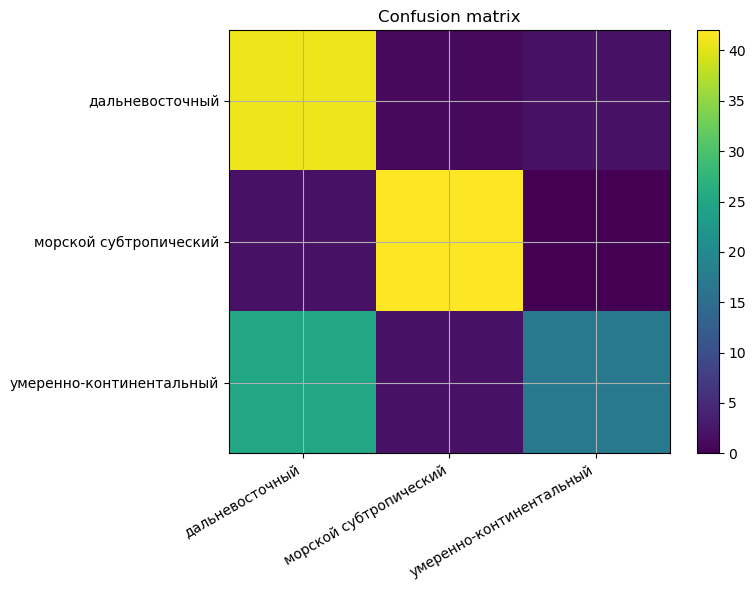

In [31]:
labels = sorted(y_test_clf.unique())
cm = confusion_matrix(y_test_clf, test_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, aspect="auto")
ax.set_title("Confusion matrix")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [32]:
y_test_bin = label_binarize(y_test_clf, classes=labels)
roc_auc_ovr = roc_auc_score(y_test_bin, test_proba, multi_class="ovr", average="macro")
print("ROC-AUC OVR (macro):", round(roc_auc_ovr, 4))

ROC-AUC OVR (macro): 0.9405


,month,error_rate,n_samples
0,1,0.166667,6
1,2,0.333333,12
2,3,0.333333,12
3,4,0.166667,12
4,5,0.250000,12
5,6,0.166667,12
6,7,0.250000,12
7,8,0.333333,12
8,9,0.250000,12
9,10,0.250000,12


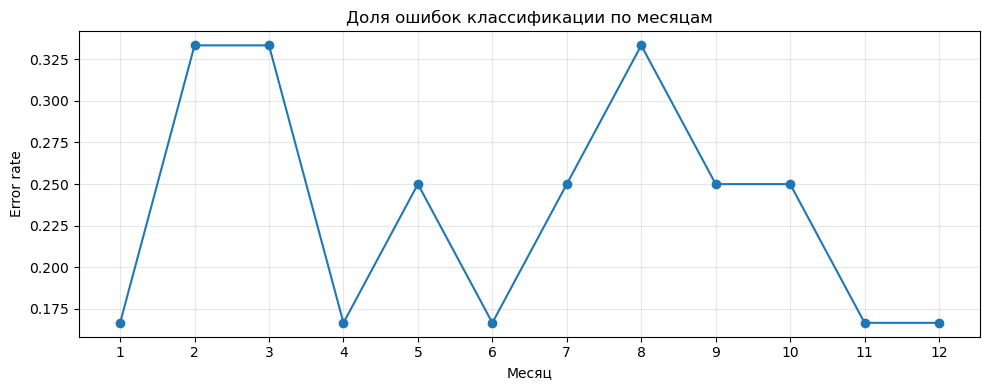

,season,error_rate,n_samples
3,winter,0.250000,24
1,spring,0.250000,36
2,summer,0.250000,36
0,autumn,0.222222,36


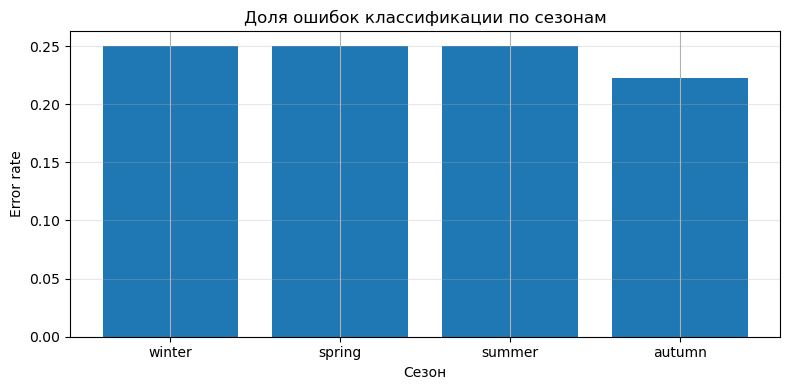

In [36]:
def get_season(month: int) -> str:
    if month in [12, 1, 2]:
        return "winter"
    if month in [3, 4, 5]:
        return "spring"
    if month in [6, 7, 8]:
        return "summer"
    return "autumn"


# Анализ ошибок классификации по месяцам и сезонам
test_eval = test_clf[["city", "climate_type", "month"]].copy()
test_eval["pred"] = test_pred
test_eval["is_error"] = (test_eval["climate_type"] != test_eval["pred"]).astype(int)
test_eval["season"] = test_eval["month"].apply(get_season)


# Ошибки по месяцам
monthly_error = (
    test_eval
    .groupby("month", as_index=False)
    .agg(
        error_rate=("is_error", "mean"),
        n_samples=("is_error", "size"),
    )
)

display(monthly_error)


fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    monthly_error["month"],
    monthly_error["error_rate"],
    marker="o"
)

ax.set_title("Доля ошибок классификации по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Error rate")
ax.set_xticks(range(1, 13))
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Ошибки по сезонам
season_order = ["winter", "spring", "summer", "autumn"]

seasonal_error = (
    test_eval
    .groupby("season", as_index=False)
    .agg(
        error_rate=("is_error", "mean"),
        n_samples=("is_error", "size"),
    )
)

seasonal_error["season"] = pd.Categorical(
    seasonal_error["season"],
    categories=season_order,
    ordered=True
)

seasonal_error = seasonal_error.sort_values("season")

display(seasonal_error)


fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    seasonal_error["season"].astype(str),
    seasonal_error["error_rate"]
)

ax.set_title("Доля ошибок классификации по сезонам")
ax.set_xlabel("Сезон")
ax.set_ylabel("Error rate")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

,feature,importance_mean,importance_std
33,surface_pressure_min,0.146212,0.028356
26,wind_speed_10m_mean,0.021970,0.013741
32,surface_pressure_std,0.018182,0.008436
31,surface_pressure_mean,0.014394,0.007909
34,surface_pressure_max,0.008333,0.004080
19,rain_max,0.005303,0.004851
9,relative_humidity_2m_max,0.005303,0.003472
14,precipitation_max,0.004545,0.003711
24,snowfall_max,0.003788,0.003788
1,temperature_2m_mean,0.003788,0.008470


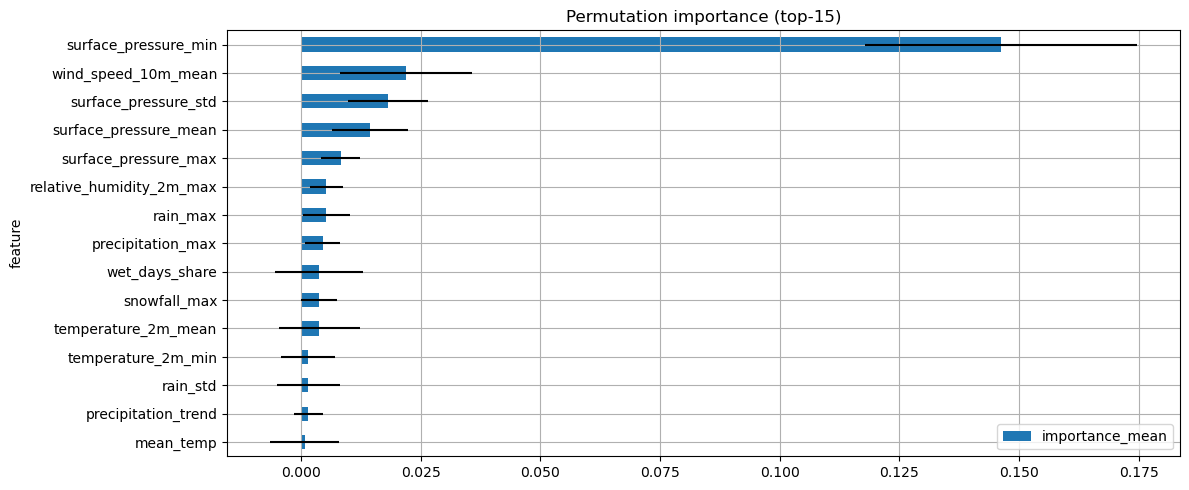

In [37]:
perm = permutation_importance(
    clf_pipe,
    X_test_clf,
    y_test_clf,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame(
    {
        "feature": feature_cols_clf,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

display(perm_df.head(20))

perm_df.head(15).sort_values("importance_mean").plot.barh(
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    title="Permutation importance (top-15)"
)
plt.tight_layout()
plt.show()

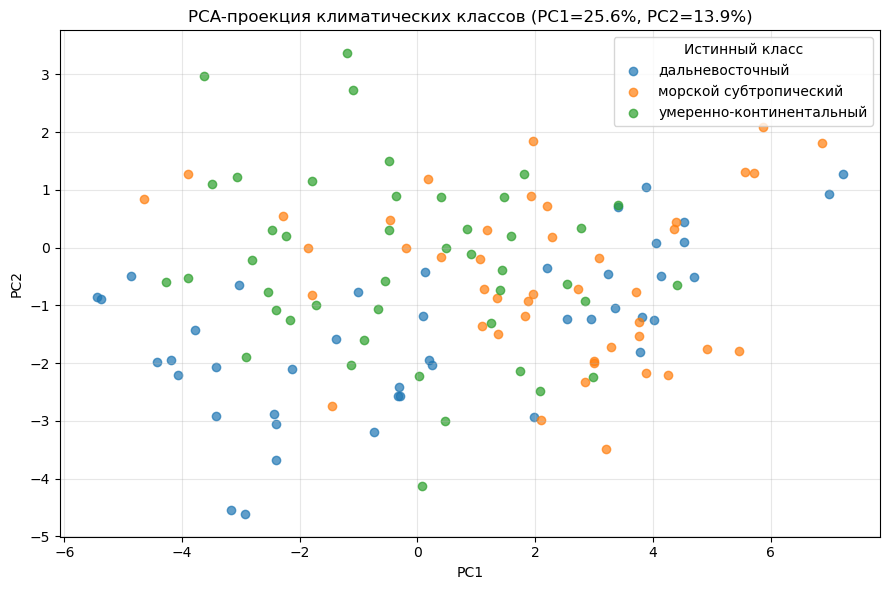

In [39]:
# PCA-визуализация разделимости климатических классов
pca_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])

X_train_pca = pca_pipe.fit_transform(X_train_clf)
X_test_pca = pca_pipe.transform(X_test_clf)

pca_vis = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"], index=X_test_clf.index)
pca_vis["true_class"] = y_test_clf.values
pca_vis["pred_class"] = test_pred

explained_var = pca_pipe.named_steps["pca"].explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))

for climate_type, sub in pca_vis.groupby("true_class"):
    ax.scatter(
        sub["PC1"],
        sub["PC2"],
        label=climate_type,
        alpha=0.7
    )

ax.set_title(
    "PCA-проекция климатических классов "
    f"(PC1={explained_var[0]:.1%}, PC2={explained_var[1]:.1%})"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(title="Истинный класс")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Вывод по классификации
Наиболее естественно интерпретируются ошибки между климатами, имеющими частично схожие сезонные профили.  
Permutation importance обычно показывает высокую значимость:
- температурной амплитуды,
- средней температуры,
- доли влажных дней,
- признаков давления и ветра.

## 7. Подготовка датасета для прогнозирования

In [40]:
FORECAST_BASE_COLS = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "rain",
    "snowfall",
    "wind_speed_10m",
    "surface_pressure",
]


def build_forecast_dataset(
    city_df: pd.DataFrame,
    target: str = "temperature_2m",
    history: int = 30,
    horizon: int = 30,
) -> tuple[pd.DataFrame, np.ndarray, pd.Series]:
    city_df = city_df.sort_values("time").reset_index(drop=True).copy()

    rows = []
    targets = []
    meta = []

    for i in range(history, len(city_df) - horizon + 1):
        hist = city_df.iloc[i - history:i]
        current = city_df.iloc[i]

        feat = {}
        for col in FORECAST_BASE_COLS:
            values = hist[col].values
            feat[f"{col}_last"] = values[-1]
            feat[f"{col}_mean_7"] = values[-7:].mean()
            feat[f"{col}_mean_14"] = values[-14:].mean()
            feat[f"{col}_mean_30"] = values.mean()
            feat[f"{col}_std_7"] = values[-7:].std()
            feat[f"{col}_std_30"] = values.std()
            feat[f"{col}_min_30"] = values.min()
            feat[f"{col}_max_30"] = values.max()
            feat[f"{col}_trend_7"] = safe_trend(values[-7:])
            feat[f"{col}_trend_30"] = safe_trend(values)

        feat["dayofweek"] = current["dayofweek"]
        feat["month"] = current["month"]
        feat["dayofyear"] = current["dayofyear"]
        feat["month_sin"] = current["month_sin"]
        feat["month_cos"] = current["month_cos"]
        feat["doy_sin"] = current["doy_sin"]
        feat["doy_cos"] = current["doy_cos"]
        feat["temperature_clim_norm"] = current.get("temperature_clim_norm", np.nan)
        feat["temperature_anomaly"] = current.get("temperature_anomaly", np.nan)

        rows.append(feat)
        targets.append(city_df[target].iloc[i:i + horizon].values)
        meta.append(city_df["time"].iloc[i])

    X = pd.DataFrame(rows)
    y = np.vstack(targets)
    meta = pd.Series(meta, name="forecast_start")
    return X, y, meta


def temporal_split(X: pd.DataFrame, y: np.ndarray, meta: pd.Series):
    years = pd.to_datetime(meta).dt.year
    train_idx = years <= 2023
    val_idx = years == 2024
    test_idx = years == 2025

    return (
        X.loc[train_idx].reset_index(drop=True),
        X.loc[val_idx].reset_index(drop=True),
        X.loc[test_idx].reset_index(drop=True),
        y[train_idx.values],
        y[val_idx.values],
        y[test_idx.values],
        meta.loc[train_idx].reset_index(drop=True),
        meta.loc[val_idx].reset_index(drop=True),
        meta.loc[test_idx].reset_index(drop=True),
    )

### Обоснование моделей прогнозирования

Для каждого города можно выбирать отдельную модель, так как погодные ряды различаются по сезонности, волатильности и чувствительности к метеофакторам: осадкам, влажности, ветру и давлению.

В notebook сравниваются несколько практичных моделей:

- **Ridge** в multi-output режиме — сильный линейный baseline для прогноза сразу на несколько дней вперёд;
- **RandomForestRegressor** — нелинейная ансамблевая модель для учёта сложных зависимостей;
- **ExtraTreesRegressor** — более рандомизированный ансамбль, устойчивый к шуму и избыточным признакам.

#### Почему не используем другие подходы

- **Константа / last value** подходят только как baseline, но не как финальная модель.
- **Модель на одном лаге** игнорирует сезонность, динамику и накопленный погодный контекст.
- **Линейная экстраполяция тренда** плохо описывает погодные колебания и смену синоптических режимов.

In [42]:
candidate_models = {
    "ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=3.0)),
    ]),

    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=250,
            max_depth=12,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),

    "extra_trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(
            n_estimators=300,
            max_depth=14,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}


def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(
        np.sqrt(mean_squared_error(y_true, y_pred))
    )


def mape_safe(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    eps: float = 1e-6,
) -> float:
    """MAPE с защитой от деления на ноль. Для температуры используется только как вспомогательная метрика."""
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.maximum(np.abs(y_true), eps)
    return float(
        np.mean(np.abs((y_true - y_pred) / denom)) * 100
    )


def wape(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    eps: float = 1e-6,
) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    numerator = np.abs(y_true - y_pred).sum()
    denominator = np.maximum(np.abs(y_true).sum(), eps)

    return float(numerator / denominator * 100)


def direction_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Доля совпадения направления изменения прогноза и факта по горизонту."""
    
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    true_direction = np.sign(np.diff(y_true, axis=1))
    pred_direction = np.sign(np.diff(y_pred, axis=1))

    return float((true_direction == pred_direction).mean() * 100)


def forecast_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape_safe(y_true, y_pred),
        "WAPE_%": wape(y_true, y_pred),
        "Direction_Acc_%": direction_accuracy(y_true, y_pred),
    }

In [45]:
def horizon_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    rows = []

    for h in range(y_true.shape[1]):
        rows.append({
            "horizon_day": h + 1,
            "MAE": mean_absolute_error(y_true[:, h], y_pred[:, h]),
            "RMSE": rmse(y_true[:, h], y_pred[:, h]),
            "WAPE_%": wape(y_true[:, h], y_pred[:, h]),
        })

    return pd.DataFrame(rows)

In [46]:
city_model_results = []
horizon_results = []
best_models = {}
forecast_test_store = {}

for city in sorted(daily_features_df["city"].unique()):
    city_df = daily_features_df[daily_features_df["city"] == city].copy()

    X, y, meta = build_forecast_dataset(
        city_df,
        target="temperature_2m",
        history=30,
        horizon=30
    )

    (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
        meta_train,
        meta_val,
        meta_test,
    ) = temporal_split(X, y, meta)

    best_name = None
    best_val_mae = np.inf
    best_model = None

    # Подбор лучшей модели по validation
    for model_name, model in candidate_models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train)

        val_pred = fitted_model.predict(X_val)
        val_metrics = forecast_metrics(y_val, val_pred)

        city_model_results.append({
            "city": city,
            "model": model_name,
            "split": "val",
            **val_metrics,
        })

        if val_metrics["MAE"] < best_val_mae:
            best_val_mae = val_metrics["MAE"]
            best_name = model_name
            best_model = fitted_model

    # Финальное обучение лучшей модели на train + val
    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = np.vstack([y_train, y_val])

    final_model = clone(candidate_models[best_name])
    final_model.fit(X_train_full, y_train_full)

    # Оценка на test
    test_pred = final_model.predict(X_test)
    test_metrics = forecast_metrics(y_test, test_pred)

    city_model_results.append({
        "city": city,
        "model": best_name,
        "split": "test",
        **test_metrics,
    })

    # Ошибки по горизонтам прогноза
    city_horizon_metrics = horizon_metrics(y_test, test_pred)
    city_horizon_metrics["city"] = city
    city_horizon_metrics["model"] = best_name
    horizon_results.append(city_horizon_metrics)

    # Сохраняем финальную модель и test-прогнозы
    best_models[city] = {
        "name": best_name,
        "model": final_model,
        "feature_columns": X.columns.tolist(),
    }

    forecast_test_store[city] = {
        "X_test": X_test,
        "y_test": y_test,
        "pred_test": test_pred,
        "meta_test": meta_test,
    }


forecast_metrics_df = pd.DataFrame(city_model_results)
forecast_horizon_metrics_df = pd.concat(horizon_results, ignore_index=True)

display(forecast_metrics_df)
display(forecast_horizon_metrics_df)

,city,model,split,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%
0,Благовещенск,ridge,val,2.804187,3.583781,59.373939,19.895407,54.032410
1,Благовещенск,random_forest,val,2.695682,3.500765,44.387811,19.125574,54.390428
2,Благовещенск,extra_trees,val,2.668961,3.477702,44.436733,18.935992,54.663652
3,Благовещенск,extra_trees,test,2.814842,3.676061,57.806963,20.202766,55.439245
4,Геленджик,ridge,val,2.805063,3.653049,58.602437,18.477750,51.620501
5,Геленджик,random_forest,val,2.841135,3.596800,67.078756,18.715367,50.169587
6,Геленджик,extra_trees,val,2.883052,3.670138,68.736435,18.991484,50.028265
7,Геленджик,ridge,test,2.888941,3.755591,88.392435,19.342578,52.832512
8,Москва,ridge,val,3.686979,4.803452,241.713874,34.835148,52.506124
9,Москва,random_forest,val,3.663123,4.639426,306.897487,34.609753,51.893725


,horizon_day,MAE,RMSE,WAPE_%,city,model
0,1,2.669284,3.492901,18.998078,Благовещенск,extra_trees
1,2,2.822981,3.673005,20.114921,Благовещенск,extra_trees
2,3,2.854294,3.736521,20.378174,Благовещенск,extra_trees
3,4,2.864615,3.782122,20.505383,Благовещенск,extra_trees
4,5,2.866391,3.793704,20.578268,Благовещенск,extra_trees
...,...,...,...,...,...,...
175,26,2.655482,3.496762,17.435850,Сочи,ridge
176,27,2.666216,3.507546,17.516800,Сочи,ridge
177,28,2.703384,3.519739,17.773183,Сочи,ridge
178,29,2.738683,3.531262,18.018736,Сочи,ridge


## 8. Оценка качества прогнозирования

In [47]:
test_metrics_df = forecast_metrics_df[forecast_metrics_df["split"] == "test"].copy()
display(test_metrics_df.sort_values("MAE"))

,city,model,split,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%
15,Находка,ridge,test,2.409167,3.190003,78.972931,20.577288,53.150657
23,Сочи,ridge,test,2.438501,3.279573,42.572907,16.023224,53.314860
3,Благовещенск,extra_trees,test,2.814842,3.676061,57.806963,20.202766,55.439245
7,Геленджик,ridge,test,2.888941,3.755591,88.392435,19.342578,52.832512
19,Санкт-Петербург,ridge,test,3.001452,3.775987,197.163015,32.157651,53.335386
11,Москва,extra_trees,test,3.765385,4.524637,234.712490,36.618517,51.211002


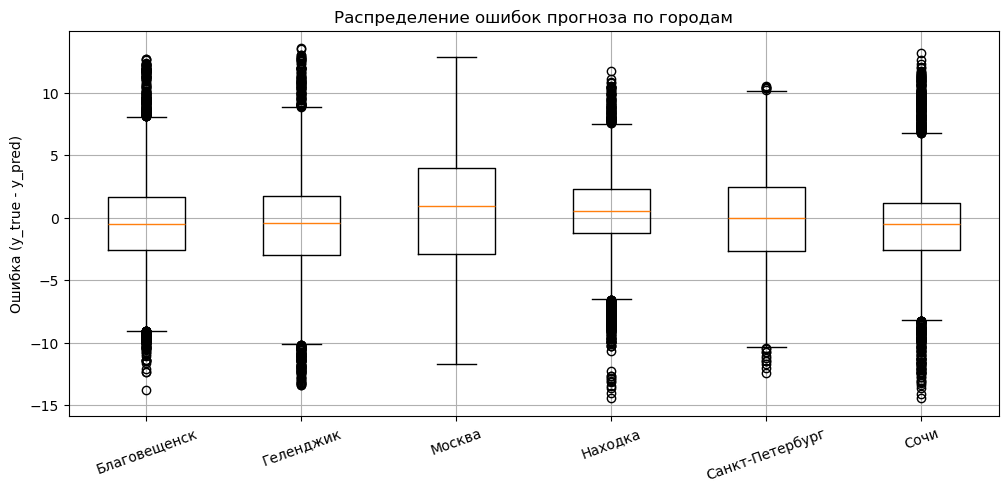

In [48]:
# Boxplot ошибок по городам
errors_for_boxplot = []
labels_box = []

for city, store in forecast_test_store.items():
    err = (store["y_test"] - store["pred_test"]).ravel()
    errors_for_boxplot.append(err)
    labels_box.append(city)

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(errors_for_boxplot, tick_labels=labels_box)
ax.set_title("Распределение ошибок прогноза по городам")
ax.set_ylabel("Ошибка (y_true - y_pred)")
plt.xticks(rotation=20)
plt.show()

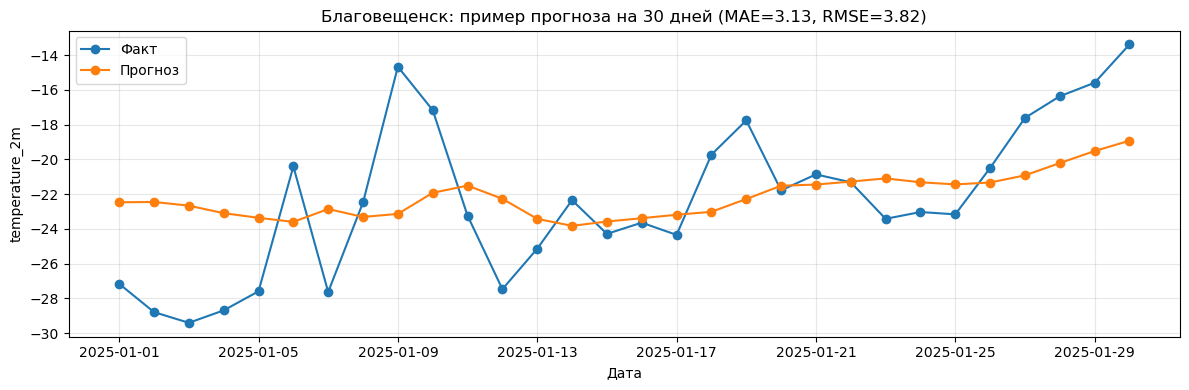

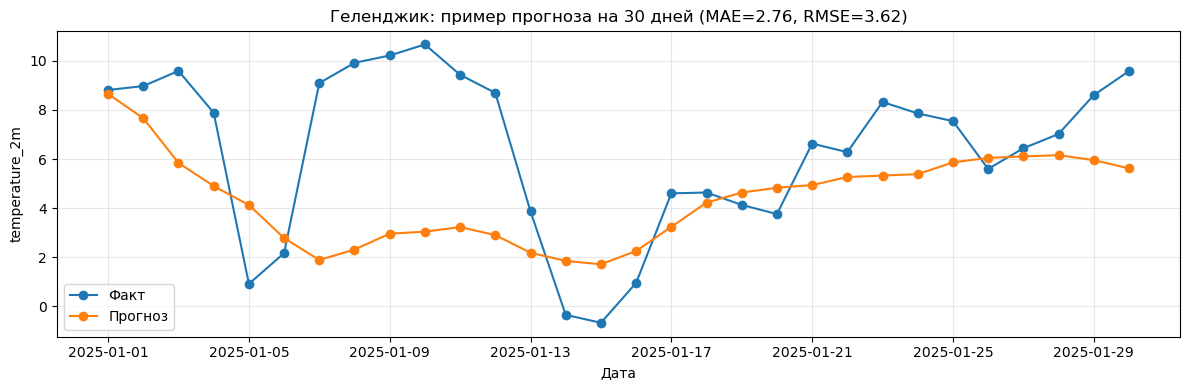

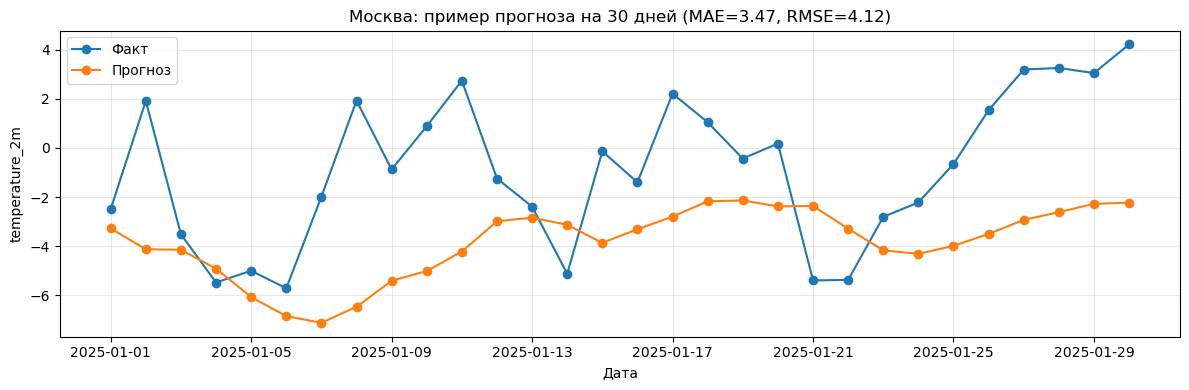

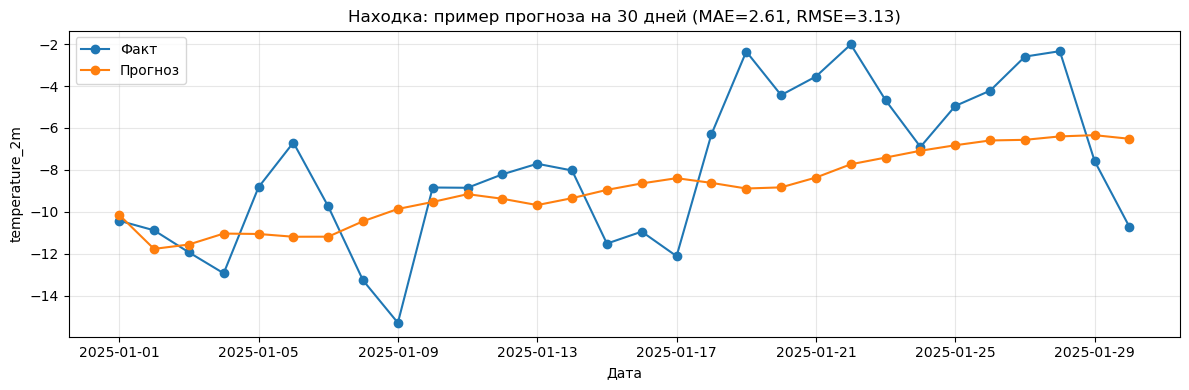

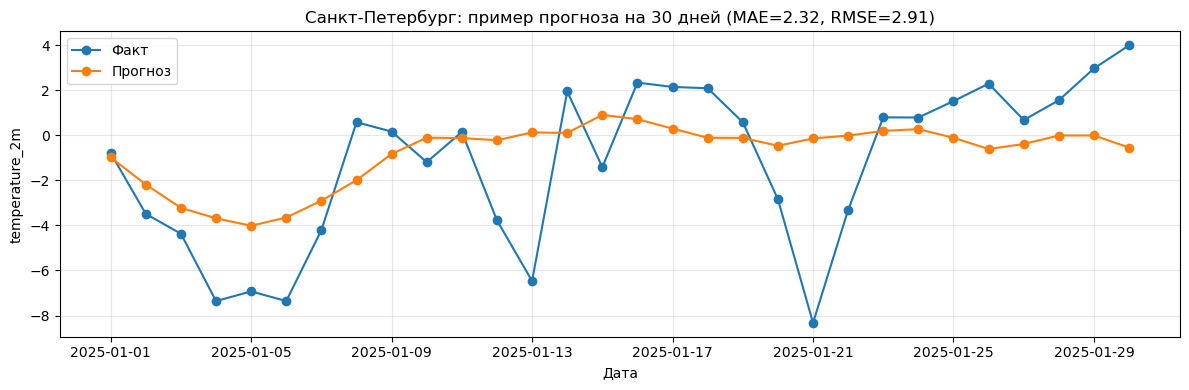

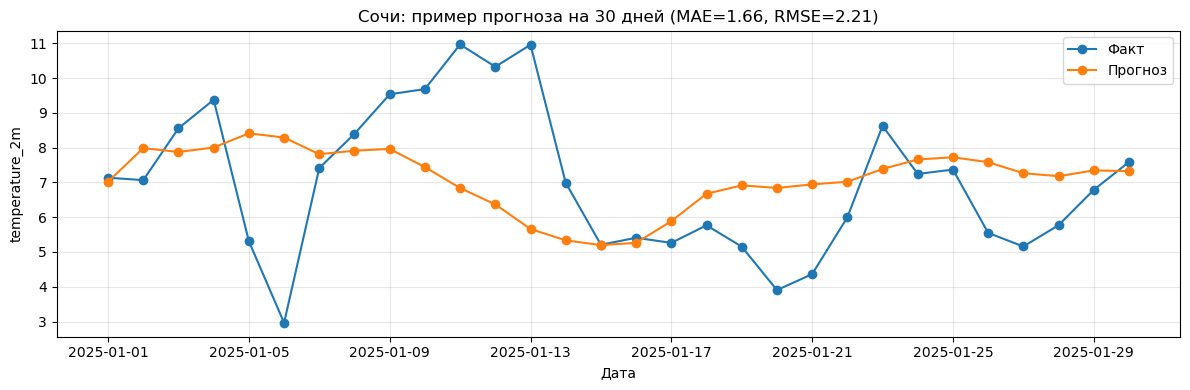

In [50]:
def plot_forecast_example(
    forecast_test_store: dict,
    city: str,
    idx: int = 0,
    target_name: str = "temperature_2m",
) -> None:
    """Строит пример 30-дневного прогноза для выбранного города и объекта test-выборки."""

    store = forecast_test_store[city]

    y_true = store["y_test"][idx]
    y_pred = store["pred_test"][idx]

    start_date = pd.to_datetime(store["meta_test"].iloc[idx])
    horizon_dates = pd.date_range(
        start=start_date,
        periods=len(y_true),
        freq="D"
    )

    plot_df = pd.DataFrame({
        "time": horizon_dates,
        "actual": y_true,
        "forecast": y_pred,
    })

    example_mae = mean_absolute_error(y_true, y_pred)
    example_rmse = rmse(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        plot_df["time"],
        plot_df["actual"],
        marker="o",
        label="Факт"
    )

    ax.plot(
        plot_df["time"],
        plot_df["forecast"],
        marker="o",
        label="Прогноз"
    )

    ax.set_title(
        f"{city}: пример прогноза на 30 дней "
        f"(MAE={example_mae:.2f}, RMSE={example_rmse:.2f})"
    )
    ax.set_xlabel("Дата")
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


# Примеры месячного прогноза на test для каждого города
for city in sorted(forecast_test_store):
    plot_forecast_example(
        forecast_test_store,
        city=city,
        idx=0,
        target_name="temperature_2m"
    )

In [51]:
# Остаточный анализ: используем horizon-1 и также общий массив ошибок
residual_tests = []

for city, store in forecast_test_store.items():
    y_true = store["y_test"]
    y_pred = store["pred_test"]

    residuals_all = (y_true - y_pred).ravel()
    residuals_h1 = (y_true[:, 0] - y_pred[:, 0]).ravel()

    sample_for_shapiro = residuals_all
    if len(sample_for_shapiro) > 5000:
        rng = np.random.default_rng(RANDOM_STATE)
        sample_for_shapiro = rng.choice(sample_for_shapiro, size=5000, replace=False)

    shapiro_stat, shapiro_p = stats.shapiro(sample_for_shapiro)

    lb = acorr_ljungbox(residuals_h1, lags=[10], return_df=True)
    lb_stat = float(lb["lb_stat"].iloc[0])
    lb_p = float(lb["lb_pvalue"].iloc[0])

    # White test на horizon-1
    X_white = sm.add_constant(store["pred_test"][:, [0]])
    white_stat, white_p, _, _ = het_white(residuals_h1, X_white)

    residual_tests.append({
        "city": city,
        "shapiro_pvalue": shapiro_p,
        "ljung_box_pvalue_lag10": lb_p,
        "white_pvalue": white_p,
        "h1_residual_mean": residuals_h1.mean(),
        "h1_residual_std": residuals_h1.std(),
    })

residual_tests_df = pd.DataFrame(residual_tests)
display(residual_tests_df)

,city,shapiro_pvalue,ljung_box_pvalue_lag10,white_pvalue,h1_residual_mean,h1_residual_std
0,Благовещенск,1.247168e-16,3.341902e-52,0.000484,-0.366529,3.473616
1,Геленджик,8.029277e-16,3.504883e-52,0.095000,0.005384,0.061353
2,Москва,9.897851e-17,4.876051e-121,0.000288,0.084710,3.661505
3,Находка,2.136859e-24,6.074833e-152,0.000002,-0.007382,0.145296
4,Санкт-Петербург,1.851115e-11,2.770874e-59,0.000778,-0.000918,0.084672
5,Сочи,1.292620e-28,6.749130e-45,0.084100,0.025573,0.070149


### Интерпретация остаточного анализа
- **Shapiro-Wilk**: проверяет нормальность остатков;
- **Ljung-Box**: проверяет наличие автокорреляции в остатках;
- **White test**: проверяет гетероскедастичность.

Для реальных погодных данных идеальная нормальность встречается редко, поэтому важнее смотреть на:
- отсутствие систематического смещения,
- ограниченный масштаб автокорреляции,
- устойчивость ошибки между городами.

## 9. Интеграция двух этапов в единый пайплайн

In [60]:
# Климатическая норма по дню года
clim_norm = (
    daily_features_df
    .groupby(["city", "dayofyear"], as_index=False)["temperature_2m"]
    .mean()
    .rename(columns={"temperature_2m": "temperature_clim_norm"})
)


# Прототипы городов внутри климатических зон: нужны, если город неизвестен, а известен только ряд
city_prototypes = (
    clf_df.groupby("city")[
        [c for c in clf_df.columns if c not in ["city", "climate_type", "start_time", "end_time"]]
    ]
    .mean()
)

city_to_climate = {city: climate for city, climate in CLIMATE_MAP.items()}


class TwoStageWeatherPipeline:
    def __init__(self, classifier, city_models, city_prototypes, climate_map, clim_norm):
        self.classifier = classifier
        self.city_models = city_models
        self.city_prototypes = city_prototypes
        self.climate_map = climate_map
        self.clim_norm = clim_norm

    def _build_classification_features(self, recent_daily_window: pd.DataFrame) -> pd.DataFrame:
        tmp = recent_daily_window.copy().sort_values("time")
        tmp["climate_type"] = "unknown"

        tmp["season"] = np.select(
            [
                tmp["month"].isin([12, 1, 2]),
                tmp["month"].isin([3, 4, 5]),
                tmp["month"].isin([6, 7, 8]),
                tmp["month"].isin([9, 10, 11]),
            ],
            ["winter", "spring", "summer", "autumn"],
            default="unknown",
        )

        feats = build_classification_windows(tmp, window=len(tmp), step=len(tmp))
        feats = pd.get_dummies(feats, columns=["season"], drop_first=False)

        for col in feature_cols_clf:
            if col not in feats.columns:
                feats[col] = 0

        return feats[feature_cols_clf]

    def _guess_city_within_climate(self, feature_vector: pd.DataFrame, predicted_climate: str) -> str:
        candidate_cities = [
            city
            for city, climate in self.climate_map.items()
            if climate == predicted_climate
        ]

        prototype_space = self.city_prototypes.loc[
            candidate_cities,
            [c for c in self.city_prototypes.columns if c in feature_vector.columns]
        ]

        vec = feature_vector[prototype_space.columns].iloc[0].values.astype(float)

        distances = {}
        for city in candidate_cities:
            proto = prototype_space.loc[city].values.astype(float)
            distances[city] = np.linalg.norm(vec - proto)

        return min(distances, key=distances.get)

    def _build_forecast_features(self, recent_daily_window: pd.DataFrame) -> pd.DataFrame:
        hist = recent_daily_window.copy().sort_values("time").reset_index(drop=True)
        hist = add_time_features(hist)

        feat = {}

        for col in FORECAST_BASE_COLS:
            values = hist[col].values

            feat[f"{col}_last"] = values[-1]
            feat[f"{col}_mean_7"] = values[-7:].mean()
            feat[f"{col}_mean_14"] = values[-14:].mean()
            feat[f"{col}_mean_30"] = values.mean()
            feat[f"{col}_std_7"] = values[-7:].std()
            feat[f"{col}_std_30"] = values.std()
            feat[f"{col}_min_30"] = values.min()
            feat[f"{col}_max_30"] = values.max()
            feat[f"{col}_trend_7"] = safe_trend(values[-7:])
            feat[f"{col}_trend_30"] = safe_trend(values)

        current = hist.iloc[-1]

        feat["dayofweek"] = current["dayofweek"]
        feat["month"] = current["month"]
        feat["dayofyear"] = current["dayofyear"]
        feat["month_sin"] = current["month_sin"]
        feat["month_cos"] = current["month_cos"]
        feat["doy_sin"] = current["doy_sin"]
        feat["doy_cos"] = current["doy_cos"]

        dayofyear = int(current["dayofyear"])
        city = hist["city"].iloc[-1] if "city" in hist.columns else None

        if city is not None:
            norm_value = self.clim_norm[
                (self.clim_norm["city"] == city)
                & (self.clim_norm["dayofyear"] == dayofyear)
            ]["temperature_clim_norm"]

            norm_value = float(norm_value.iloc[0]) if len(norm_value) else np.nan
        else:
            norm_value = np.nan

        feat["temperature_clim_norm"] = norm_value
        feat["temperature_anomaly"] = (
            current["temperature_2m"] - norm_value
            if not pd.isna(norm_value)
            else np.nan
        )

        return pd.DataFrame([feat])

    def predict(self, recent_daily_window: pd.DataFrame, city: str | None = None) -> dict:
        if len(recent_daily_window) < 30:
            raise ValueError("Для предсказания нужно не менее 30 дней daily-данных")

        recent = recent_daily_window.sort_values("time").tail(30).copy()

        clf_features = self._build_classification_features(recent)
        predicted_climate = self.classifier.predict(clf_features)[0]

        inferred_city = city
        if inferred_city is None:
            inferred_city = self._guess_city_within_climate(clf_features, predicted_climate)

        forecast_features = self._build_forecast_features(
            recent.assign(city=inferred_city)
        )

        model_bundle = self.city_models[inferred_city]

        # Приводим признаки к тем колонкам, на которых обучалась модель города
        for col in model_bundle["feature_columns"]:
            if col not in forecast_features.columns:
                forecast_features[col] = np.nan

        forecast_features = forecast_features[model_bundle["feature_columns"]]

        forecast = model_bundle["model"].predict(forecast_features)[0]

        start_date = pd.to_datetime(recent["time"].max()) + pd.Timedelta(days=1)
        forecast_dates = pd.date_range(start_date, periods=len(forecast), freq="D")

        return {
            "predicted_climate_type": predicted_climate,
            "selected_city_model": inferred_city,
            "model_name": model_bundle["name"],
            "forecast": pd.DataFrame({
                "date": forecast_dates,
                "temperature_forecast": forecast,
            }),
        }


two_stage_pipeline = TwoStageWeatherPipeline(
    classifier=clf_pipe,
    city_models=best_models,
    city_prototypes=city_prototypes,
    climate_map=CLIMATE_MAP,
    clim_norm=clim_norm,
)

In [61]:
# Демонстрация пайплайна на последних 30 днях любого города из теста
demo_city = "Москва"
demo_window = daily_features_df[daily_features_df["city"] == demo_city].sort_values("time").tail(30)

demo_result = two_stage_pipeline.predict(demo_window, city=demo_city)
print("Предсказанный тип климата:", demo_result["predicted_climate_type"])
print("Выбранная модель города:", demo_result["selected_city_model"])
print("Название модели:", demo_result["model_name"])
display(demo_result["forecast"].head())

Предсказанный тип климата: дальневосточный
Выбранная модель города: Москва
Название модели: extra_trees


,date,temperature_forecast
0,2026-01-01,-4.215133
1,2026-01-02,-4.138854
2,2026-01-03,-4.006059
3,2026-01-04,-3.812723
4,2026-01-05,-4.021085


### Логика единого пайплайна

Единый пайплайн работает в два этапа:

1. Берутся последние 30 дней daily-метеоданных.
2. По этому окну рассчитываются статистические признаки.
3. Классификатор определяет климатический тип.
4. По климатическому типу и/или известному городу выбирается специализированная городская модель.
5. Выбранная модель строит прогноз температуры на следующие 30 дней.

Такой подход удобен для эксплуатации: классификатор выполняет роль маршрутизатора, а прогнозная модель отвечает за специализированный прогноз с учётом особенностей конкретного города.

## 10. Итоговая сводная таблица результатов

In [62]:
classification_final = metrics_summary.copy()
classification_final["stage"] = "classification"

forecast_final = test_metrics_df.copy()
forecast_final["stage"] = "forecast"

display(classification_final)
display(forecast_final.sort_values("MAE"))

,metric,value,stage
0,accuracy,0.757576,classification
1,precision_macro,0.810337,classification
2,recall_macro,0.757576,classification
3,f1_macro,0.738549,classification
4,f1_weighted,0.738549,classification


,city,model,split,MAE,RMSE,MAPE_%,WAPE_%,Direction_Acc_%,stage
15,Находка,ridge,test,2.409167,3.190003,78.972931,20.577288,53.150657,forecast
23,Сочи,ridge,test,2.438501,3.279573,42.572907,16.023224,53.314860,forecast
3,Благовещенск,extra_trees,test,2.814842,3.676061,57.806963,20.202766,55.439245,forecast
7,Геленджик,ridge,test,2.888941,3.755591,88.392435,19.342578,52.832512,forecast
19,Санкт-Петербург,ridge,test,3.001452,3.775987,197.163015,32.157651,53.335386,forecast
11,Москва,extra_trees,test,3.765385,4.524637,234.712490,36.618517,51.211002,forecast


## 11. Финальные аналитические выводы

### EDA

- Для всех городов характерна выраженная годовая сезонность температуры.
- Осадки распределены неравномерно: много дней с малыми значениями и редкие интенсивные всплески.
- Города заметно различаются по температурным профилям, режимам осадков, давлению и ветру.

### Признаки

- Наиболее информативны агрегаты температуры, признаки влажности/осадков, а также статистики давления и ветра.
- Переход к daily-частоте является практичным решением для горизонта прогноза 30 дней: он снижает шум и сохраняет сезонную структуру.
- Климатическую норму полезно дополнять температурной аномалией относительно дня года.

### Классификация

- Классификация по 30-дневному окну даёт интерпретируемый способ определить климатический режим.
- Ошибки чаще ожидаемы в переходные сезоны, когда погодные режимы разных климатических классов становятся менее различимыми.
- RandomForestClassifier подходит как устойчивый baseline для классификации по агрегированным статистическим признакам.

### Прогнозирование

- Отдельные модели по городам предпочтительнее одной универсальной модели, так как лучше учитывают локальную сезонность и волатильность.
- Месячный прогноз температуры остаётся сложной задачей, но лаговые, rolling- и календарные признаки дают устойчивый baseline.
- Ошибку прогноза важно анализировать не только в среднем по всем 30 дням, но и отдельно по горизонту, так как качество обычно ухудшается к дальним датам.

### Двухэтапный подход

- Two-stage pipeline можно использовать как производственный baseline: классификатор определяет климатический режим, а прогнозный блок выбирает специализированную модель.
- Такой подход удобен для масштабирования на новые города, особенно если город неизвестен, но доступна недавняя история погодного ряда.
- Дальнейшие улучшения возможны за счёт прогноза осадков, вероятностных интервалов, сезонной маршрутизации моделей и более сложных sequence-подходов при наличии большего объёма данных.